# 04 · Advanced SQL Analysis, Cross-Dataset Relational Joins & KPI Development

> **Pipeline Phase:** 04 — Statistical Modeling, Multi-Table SQL Analytics & Executive KPI Engineering  
> **Environment:** In-Memory SQLite Relational Engine (`:memory:`) + Python (pandas, matplotlib, seaborn)  
> **Input Datasets:** Statistics Canada (CCHS Tables 13-10-0096, 13-10-0392, 13-10-0863, CSS 45-10-0081, MHACS 2022 PUMF) & Canadian Institute for Health Information (CIHI Child/Youth & Services)  
> **Downstream Consumer:** Interactive Multi-Page Plotly Dash Executive Dashboard (`notebooks/05_dashboard.py` / `reports/`)

---

## Analytical Architecture & Executive Overview

This notebook serves as the **core analytical and KPI engine** of the Canadian Mental Health Analytics Project. Building directly upon the disambiguated and standardized data cleaning outputs from Phase 02 (which separated prevalence percentages `_pct` from headcount volumes `_n` and resolved CIHI metric taxonomies), this notebook mounts an **in-memory SQLite relational database** to conduct advanced cross-dataset joins, window-function time-series decomposition, demographic gradient analyses, and clinical triage evaluations.

```
                           ┌────────────────────────────────────────────────────────┐
                           │          In-Memory SQLite Relational Database          │
                           └────────────────────────────────────────────────────────┘
                                                        │
         ┌───────────────────────────┬──────────────────┴─────────────┬──────────────────────────┐
         ▼                           ▼                                ▼                          ▼
┌──────────────────┐        ┌──────────────────┐           ┌──────────────────┐        ┌──────────────────┐
│  StatCan % Track │        │  StatCan N Track │           │   CIHI Services  │        │  CIHI Children   │
├──────────────────┤        ├──────────────────┤           ├──────────────────┤        ├──────────────────┤
│ suicidal_pct     │        │ suicidal_n       │           │ cihi_services    │        │ cihi_children    │
│ stress_coping_pct│        │ stress_coping_n  │           │ (metric_type:    │        │ (service:        │
│ quarterly_pct    │        │ quarterly_n      │           │  percent,        │        │  ED visit,       │
│ cchs_disorders_pct        │ cchs_disorders_n │           │  rate_per_100k,  │        │  hospitalisation)│
│ perceived_annual │        │ mhacs_pumf       │           │  mean_score)     │        │                  │
└──────────────────┘        └──────────────────┘           └──────────────────┘        └──────────────────┘
         │                           │                                │                          │
         └───────────────────────────┼────────────────────────────────┴──────────────────────────┘
                                     ▼
                     ┌────────────────────────────────┐
                     │          mh_long (View)        │
                     ├────────────────────────────────┤
                     │ 19,230 longitudinal indicator  │
                     │ rows across 5 StatCan surveys  │
                     │ for macro KPI tracking         │
                     └────────────────────────────────┘
```

### Key Analytical Pillars
1. **Longitudinal Macro Deterioration:** Evaluating national and provincial shifts in perceived mental health from 2002 to 2023, quantifying post-2019 inflection points and quarter-over-quarter adult erosion.
2. **Geographic Inequality & Disparity Ratios:** Measuring the inter-provincial spread in mental health burden, contrasting Atlantic provinces (Nova Scotia, New Brunswick) and Western provinces against Quebec and national benchmarks.
3. **The Gender Paradox (Flagship Query 1):** Uncovering the critical public health divergence between female-skewing self-reported morbidity/ideation and male-skewing suicide mortality ($3	imes$ higher male death rate).
4. **Unmet Consultation Headcount Deficit (Flagship Query 2):** Quantifying the exact population headcount of Canadians experiencing suicidal ideation without accessing professional clinical care.
5. **Coping Deficit vs. Clinical Morbidity (Flagship Query 3):** Correlating day-to-day life stress coping impairments against formal clinical diagnoses of mood and anxiety disorders across provinces using SQL ranking functions.
6. **Pediatric & Adolescent Acute Care Crisis (Flagship Queries 4 & 6):** Tracking the concurrent surge in adult perceived health decline alongside pediatric emergency room visits and psychiatric hospitalizations, computing acute triage conversion ratios by diagnostic category.
7. **Socioeconomic Gradients (Flagship Query 5):** Analyzing survey-weighted microdata from the 2022 CCHS Mental Health and Access to Care Survey (MHACS PUMF) across income brackets.
8. **Automated KPI Extraction:** Generating a structured scorecard exported to `data/processed/04_kpi_summary.csv` for dashboard wiring.


## 1 · Environment Setup & Visualization Aesthetics


In [1]:
import sqlite3
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure pandas display
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 60)

# Configure modern executive visualization aesthetics
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "figure.dpi": 120,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Helvetica", "Arial"],
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.labelsize": 11,
    "axes.labelweight": "normal",
    "axes.edgecolor": "#cccccc",
    "axes.linewidth": 1.0,
    "grid.color": "#e2e8f0",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 10,
    "legend.frameon": True,
    "legend.edgecolor": "#cbd5e1"
})

print("sqlite3 runtime version:", sqlite3.sqlite_version, "(window functions verified: >= 3.25)")



sqlite3 runtime version: 3.53.4 (window functions verified: >= 3.25)


In [2]:
def find_root(start: Path) -> Path:
    # Climb up until we find the project marker (.git or data/)
    curr = start.resolve()
    while curr != curr.parent:
        if (curr / ".git").exists() or (curr / "data").exists():
            return curr
        curr = curr.parent
    return start.resolve()

ROOT = find_root(Path.cwd())
DATA = ROOT / "data"
PROCESSED = DATA / "processed"
CLEANED = PROCESSED / "02_cleaned"

print("Project root :", ROOT)
print("Cleaned dir  :", CLEANED.relative_to(ROOT))
print("Processed dir:", PROCESSED.relative_to(ROOT))


Project root : /Users/samir/Work Related/JDA-Scrum/Data-Analyst-Mental-Health-Project-
Cleaned dir  : data/processed/02_cleaned
Processed dir: data/processed


## 2 · Load Cleaned Data into In-Memory SQLite Database

We load both the integrated longitudinal tracking tables (`mh_long`, `cihi_children`) and the discrete individual cleaned tables produced in Phase 02 into an in-memory SQLite database. This hybrid design gives us the speed of a consolidated table for standard time-series queries while enabling multi-table relational joins across percentage tracks, population headcount tracks, CIHI acute care services, and microdata.


In [3]:
con = sqlite3.connect(":memory:")
con.execute("PRAGMA journal_mode = OFF")
con.execute("PRAGMA synchronous = OFF")

# Primary integrated tables
primary_files = {
    "mh_long": PROCESSED / "mh_long.csv",
    "cihi_children": PROCESSED / "cihi_children.csv"
}

# Discrete relational tables
discrete_files = {
    "suicidal_pct": CLEANED / "suicidal_thoughts_pct.csv",
    "suicidal_n": CLEANED / "suicidal_thoughts_n.csv",
    "stress_coping_pct": CLEANED / "stress_coping_pct.csv",
    "stress_coping_n": CLEANED / "stress_coping_n.csv",
    "quarterly_pct": CLEANED / "perceived_health_quarterly_pct.csv",
    "quarterly_n": CLEANED / "perceived_health_quarterly_n.csv",
    "cchs_disorders_pct": CLEANED / "cchs_mh_disorders_pct.csv",
    "cchs_disorders_n": CLEANED / "cchs_mh_disorders_n.csv",
    "cihi_services": CLEANED / "cihi_mh_services.csv",
    "perceived_annual": CLEANED / "perceived_mh_annual.csv",
    "mhacs_pumf": CLEANED / "mhacs_2022_pumf.csv"
}

all_files = {**primary_files, **discrete_files}
loaded_stats = []

for table_name, file_path in all_files.items():
    if file_path.exists():
        # Load CSV and register into SQLite
        df = pd.read_csv(file_path, low_memory=False)
        df.to_sql(table_name, con, if_exists="replace", index=False)
        loaded_stats.append({
            "table": table_name,
            "rows": len(df),
            "columns": len(df.columns),
            "source_file": file_path.name
        })
    else:
        print(f"⚠️ Warning: {file_path.name} not found.")

df_inventory = pd.DataFrame(loaded_stats)
print(f"✓ Successfully mounted {len(loaded_stats)} relational tables into SQLite (:memory:):")
display(df_inventory)


✓ Successfully mounted 13 relational tables into SQLite (:memory:):


,table,rows,columns,source_file
0,mh_long,19230,13,mh_long.csv
1,cihi_children,4320,10,cihi_children.csv
2,suicidal_pct,1104,12,suicidal_thoughts_pct.csv
3,suicidal_n,1111,12,suicidal_thoughts_n.csv
4,stress_coping_pct,3220,12,stress_coping_pct.csv
5,stress_coping_n,3219,12,stress_coping_n.csv
6,quarterly_pct,1053,11,perceived_health_quarterly_pct.csv
7,quarterly_n,938,11,perceived_health_quarterly_n.csv
8,cchs_disorders_pct,12917,12,cchs_mh_disorders_pct.csv
9,cchs_disorders_n,12908,12,cchs_mh_disorders_n.csv


In [4]:
def q(sql: str) -> pd.DataFrame:
    # Run a SQL query against the in-memory SQLite DB and return a pandas DataFrame
    return pd.read_sql_query(textwrap.dedent(sql), con)

# Quick verification: list available indicators in mh_long
q("""
    SELECT source, indicator, COUNT(*) AS rows, MIN(year) AS min_year, MAX(year) AS max_year
    FROM mh_long 
    GROUP BY source, indicator 
    ORDER BY source, rows DESC
""").head(15)


,source,indicator,rows,min_year,max_year
0,cchs_mh_disorders,"Perceived mental health, very good or excellent",591,2002,2022
1,cchs_mh_disorders,"Perceived mental health, good",576,2002,2022
2,cchs_mh_disorders,"Cannabis use, life",573,2002,2022
3,cchs_mh_disorders,"Suicidal thoughts, life",543,2002,2022
4,cchs_mh_disorders,"Self-rated work stress, days not at all or not...",542,2002,2022
5,cchs_mh_disorders,"Perceived mental health, fair or poor",534,2002,2022
6,cchs_mh_disorders,"Self-rated work stress, days a bit stressful",531,2002,2022
7,cchs_mh_disorders,"Major depressive episode, life",518,2002,2022
8,cchs_mh_disorders,"Self-rated work stress, days quite a bit or ex...",487,2002,2022
9,cchs_mh_disorders,"Cannabis use, 12 months",485,2002,2022


## 3 · Coverage & Data-Quality Audits

Before conducting substantive epidemiological analyses, we execute baseline structural queries to verify record completeness, temporal continuity, geographic scope, quality suppression patterns, and dimensional grain uniqueness.


**Q1 · Row Counts and Dimensional Structure Across Tables**  
Verifies table scale and ensures primary tables conform to expected volumetric thresholds.


In [5]:
q("""
    SELECT 'mh_long' AS table_name, COUNT(*) AS total_rows, 'Integrated StatCan % track' AS description FROM mh_long
    UNION ALL
    SELECT 'cihi_children', COUNT(*), 'CIHI youth acute care ED & hospitalizations' FROM cihi_children
    UNION ALL
    SELECT 'suicidal_n', COUNT(*), 'StatCan ideation/consultation population headcounts' FROM suicidal_n
    UNION ALL
    SELECT 'quarterly_n', COUNT(*), 'StatCan quarterly adult population headcounts' FROM quarterly_n
    UNION ALL
    SELECT 'cchs_disorders_pct', COUNT(*), 'StatCan diagnosed conditions & care needs' FROM cchs_disorders_pct
    UNION ALL
    SELECT 'cihi_services', COUNT(*), 'CIHI health system outcomes & mortality' FROM cihi_services
    UNION ALL
    SELECT 'mhacs_pumf', COUNT(*), 'StatCan 2022 survey microdata sample' FROM mhacs_pumf;
""")


,table_name,total_rows,description
0,mh_long,19230,Integrated StatCan % track
1,cihi_children,4320,CIHI youth acute care ED & hospitalizations
2,suicidal_n,1111,StatCan ideation/consultation population headc...
3,quarterly_n,938,StatCan quarterly adult population headcounts
4,cchs_disorders_pct,12917,StatCan diagnosed conditions & care needs
5,cihi_services,263,CIHI health system outcomes & mortality
6,mhacs_pumf,9845,StatCan 2022 survey microdata sample


**Q2 · Temporal Coverage & Period Distribution per Source**  
Audits temporal depth across surveys: CCHS annual/cycle surveys (2002–2023), Quarterly Social Surveys (2021–2023), and CIHI acute care fiscal years (2018–2024).


In [6]:
q("""
    SELECT source,
           MIN(period) AS earliest_period,
           MAX(period) AS latest_period,
           COUNT(DISTINCT period) AS n_periods,
           COUNT(DISTINCT year)   AS n_years,
           COUNT(*)               AS n_rows
    FROM mh_long
    GROUP BY source
    ORDER BY n_years DESC, source;
""")


,source,earliest_period,latest_period,n_periods,n_years,n_rows
0,cchs_mh_disorders,2002,2022,3,3,12917
1,perceived_health_quarterly,2021-04,2023-07,9,3,1053
2,perceived_mh_annual,2019/2020,2023/2024,3,3,936
3,stress_coping,2016,2019,2,2,3220
4,suicidal_thoughts,2015,2019,2,2,1104


**Q3 · Geographic Coverage by Granularity Level**  
Evaluates geographic stratification across national benchmarks, 10 provinces, 3 northern territories, and aggregate regions.


In [7]:
q("""
    SELECT geo_level,
           COUNT(DISTINCT geo) AS n_geos,
           GROUP_CONCAT(DISTINCT geo) AS sample_geos
    FROM mh_long
    GROUP BY geo_level
    ORDER BY n_geos DESC;
""")


,geo_level,n_geos,sample_geos
0,province,10,"Newfoundland and Labrador,Prince Edward Island..."
1,region,4,"Atlantic Region,Prairies Region,Atlantic Provi..."
2,territory,3,"Yukon,Northwest Territories,Nunavut"
3,national,1,Canada


**Q4 · Suppressed & Marginal Quality Data by Quality Flag**  
StatCan data guidelines assign letter quality flags based on the Coefficient of Variation (CV):
* `A` / empty: High quality, CV $\le 15.0\%$.
* `B` / `E`: Marginal quality ($16.6\% < 	ext{CV} \le 33.3\%$), use with caution.
* `F`: High sampling variability, estimate suppressed for reliability/confidentiality.


In [8]:
q("""
    SELECT source,
           COALESCE(NULLIF(quality_flag, ''), 'None (Acceptable)') AS flag,
           COUNT(*) AS row_count,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY source), 1) AS pct_of_source
    FROM mh_long
    GROUP BY source, quality_flag
    ORDER BY source, row_count DESC;
""")


,source,flag,row_count,pct_of_source
0,cchs_mh_disorders,None (Acceptable),9367,72.5
1,cchs_mh_disorders,E,3550,27.5
2,perceived_health_quarterly,None (Acceptable),1053,100.0
3,perceived_mh_annual,None (Acceptable),898,95.9
4,perceived_mh_annual,..,24,2.6
5,perceived_mh_annual,E,12,1.3
6,perceived_mh_annual,F,2,0.2
7,stress_coping,None (Acceptable),2268,70.4
8,stress_coping,E,952,29.6
9,suicidal_thoughts,None (Acceptable),798,72.3


**Q5 · Primary Grain Uniqueness Validation**  
*Integrity Check:* Ensures there are zero duplicate rows at the primary analytical grain `(geo, period, sex, age_group, indicator)`. A return of 0 rows confirms full uniqueness.


In [9]:
q("""
    SELECT geo, period, sex, age_group, indicator, COUNT(*) AS count_occurrences
    FROM mh_long
    GROUP BY geo, period, sex, age_group, indicator
    HAVING COUNT(*) > 1
    LIMIT 10;
""")


,geo,period,sex,age_group,indicator,count_occurrences


## 4 · Current State: Latest-Period Macro Snapshots

In this section, we extract current national and provincial baseline statistics across key mental health dimensions, referencing published Statistics Canada and CIHI benchmarks.


**Q6 · National Headline Indicators (Canada Latest)**  
Extracts the latest national percentage for core mental health indicators, including self-rated mental health, life stress, mood/anxiety disorders, and suicidal ideation.


In [10]:
q("""
    WITH latest AS (
        SELECT indicator, MAX(year) AS max_yr
        FROM mh_long 
        WHERE geo = 'Canada' AND sex = 'Both'
        GROUP BY indicator
    )
    SELECT m.indicator, m.period AS latest_period, m.value AS prevalence_pct, m.ci_low, m.ci_high, m.source
    FROM mh_long m
    JOIN latest l ON l.indicator = m.indicator AND l.max_yr = m.year
    WHERE m.geo = 'Canada' AND m.sex = 'Both'
      AND m.age_group IN ('Total, 15 years and over', 'Total, 12 years and over', 'Total, 18 years and over')
    ORDER BY m.value DESC
    LIMIT 15;
""")


,indicator,latest_period,prevalence_pct,ci_low,ci_high,source
0,Ability to handle the day-to-day demands in li...,2019,91.0,90.5,91.3,stress_coping
1,Ability to handle unexpected and difficult pro...,2019,83.0,82.4,83.5,stress_coping
2,"Positive mental health, flourishing",2019,81.0,79.9,82.0,suicidal_thoughts
3,"Perceived need for mental health care, no need",2022,75.0,73.9,76.0,cchs_mh_disorders
4,"Perceived mental health, very good or excellent",2022,53.1,51.9,54.3,cchs_mh_disorders
5,Excellent or very good perceived health,2023-04,47.8,46.4,49.3,perceived_health_quarterly
6,Excellent or very good perceived health,2023-07,47.0,45.7,48.4,perceived_health_quarterly
7,"Cannabis use, life",2022,46.1,44.9,47.2,cchs_mh_disorders
8,"Self-rated work stress, days a bit stressful",2022,42.4,41.0,43.8,cchs_mh_disorders
9,"Any selected disorder (mental or substance), i...",2022,41.9,40.6,43.1,cchs_mh_disorders


**Q7 · Fair/Poor Perceived Mental Health by Province (Ranked Worst to Best)**  
*Online Benchmark Reference:* In the 2022–2023 CCHS releases, Nova Scotia and Saskatchewan reported the highest shares of adult population rating their mental health as fair or poor, whereas Quebec maintained the lowest provincial rate (~9%).


In [11]:
df_prov_burden = q("""
    WITH latest AS (
        SELECT MAX(year) AS max_yr 
        FROM mh_long
        WHERE indicator = 'Perceived mental health, fair or poor' AND geo_level = 'province'
    )
    SELECT m.geo AS province, m.period, m.value AS fair_poor_pct, m.ci_low, m.ci_high
    FROM mh_long m, latest
    WHERE m.indicator = 'Perceived mental health, fair or poor'
      AND m.sex = 'Both' AND m.geo_level = 'province' AND m.year = latest.max_yr
    ORDER BY m.value DESC;
""")
display(df_prov_burden)


,province,period,fair_poor_pct,ci_low,ci_high
0,Nova Scotia,2023/2024,19.7,None,None
1,British Columbia,2023/2024,17.7,None,None
2,New Brunswick,2023/2024,17.4,None,None
3,Prince Edward Island,2023/2024,17.2,None,None
4,Alberta,2023/2024,17.2,None,None
5,Saskatchewan,2023/2024,16.7,None,None
6,Newfoundland and Labrador,2023/2024,16.5,None,None
7,Ontario,2023/2024,16.3,None,None
8,Manitoba,2023/2024,16.3,None,None
9,Quebec,2023/2024,8.8,None,None


### Visual Insight 1: Provincial Mental Health Burden vs. National Benchmark
This chart highlights regional disparities across Canada, color-coding provinces that exceed the national average (red) versus those with lower reported prevalence (blue).


findfont: Failed to find font weight semibold, now using 700.


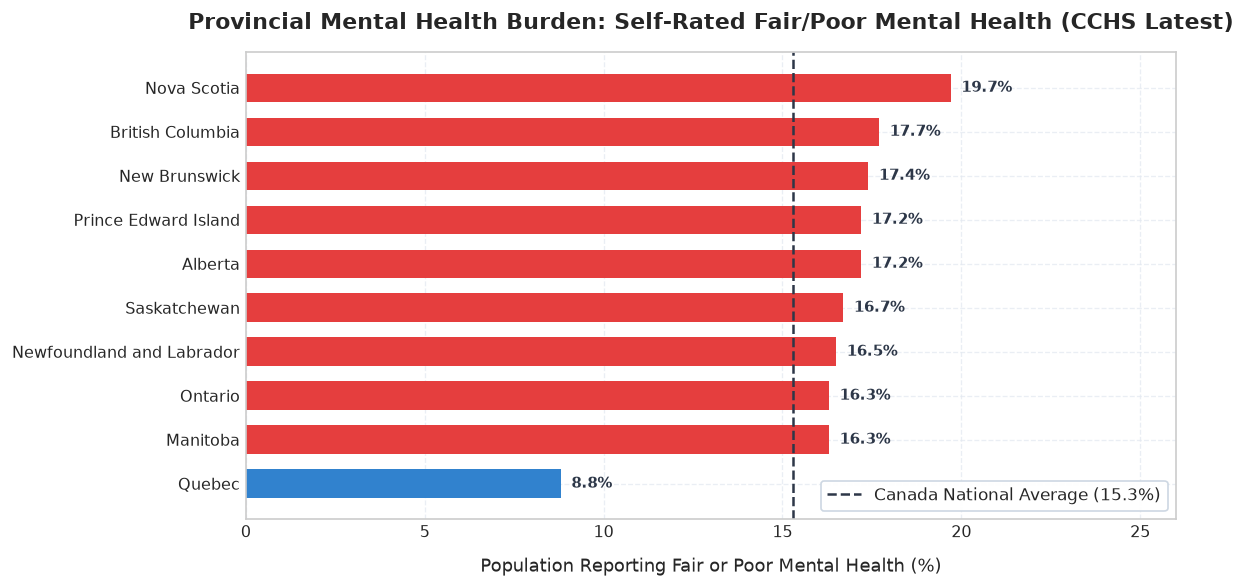

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
national_benchmark = 15.3

colors = ['#e53e3e' if v > national_benchmark else '#3182ce' for v in df_prov_burden['fair_poor_pct']]
bars = ax.barh(df_prov_burden['province'], df_prov_burden['fair_poor_pct'], color=colors, height=0.65, edgecolor='none')

# Add national benchmark vertical line
ax.axvline(national_benchmark, color='#2d3748', linestyle='--', linewidth=1.5, 
           label=f'Canada National Average ({national_benchmark}%)')

# Data value labels
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2, f'{w:.1f}%', 
            va='center', ha='left', fontsize=9, fontweight='semibold', color='#2d3748')

ax.set_xlim(0, 26)
ax.set_xlabel('Population Reporting Fair or Poor Mental Health (%)', labelpad=10)
ax.set_title('Provincial Mental Health Burden: Self-Rated Fair/Poor Mental Health (CCHS Latest)', pad=14)
ax.invert_yaxis()  # Highest at top
ax.legend(loc='lower right', framealpha=0.95)

plt.tight_layout()
plt.show()


**Q8 · Lifetime Suicidal Thoughts by Sex (National Latest)**  
Examines the self-reported prevalence of lifetime suicidal thoughts among men and women across Canada.


In [13]:
q("""
    WITH latest AS (
        SELECT MAX(year) AS max_yr 
        FROM mh_long 
        WHERE indicator LIKE 'Suicidal thoughts (15 years and over)%'
    )
    SELECT sex, period, value AS suicidal_thoughts_pct, ci_low, ci_high
    FROM mh_long, latest
    WHERE indicator LIKE 'Suicidal thoughts (15 years and over)%'
      AND geo = 'Canada' AND year = latest.max_yr
      AND age_group = 'Total, 12 years and over'
    ORDER BY suicidal_thoughts_pct DESC;
""")


,sex,period,suicidal_thoughts_pct,ci_low,ci_high
0,Female,2019,13.4,12.8,14.0
1,Both,2019,12.4,12.0,12.9
2,Male,2019,11.5,10.8,12.1


**Q9 · Every Province vs. National Average (Difference & Variance Position)**  
Quantifies percentage-point variances between provincial rates and the national baseline, identifying provinces experiencing significant excess burden.


In [14]:
q("""
    WITH latest AS (
        SELECT MAX(year) AS max_yr 
        FROM mh_long
        WHERE indicator = 'Perceived mental health, fair or poor' AND geo = 'Canada'
    ),
    nat AS (
        SELECT value AS canada_val 
        FROM mh_long, latest
        WHERE indicator = 'Perceived mental health, fair or poor'
          AND geo = 'Canada' AND sex = 'Both' AND year = latest.max_yr 
          AND age_group = 'Total, 15 years and over'
    )
    SELECT m.geo AS province,
           m.value AS province_val,
           nat.canada_val,
           ROUND(m.value - nat.canada_val, 1) AS diff_vs_canada_pp,
           CASE WHEN m.value > nat.canada_val THEN 'Above Average (Higher Burden)'
                WHEN m.value < nat.canada_val THEN 'Below Average (Lower Burden)'
                ELSE 'Equal' END AS relative_position
    FROM mh_long m, latest, nat
    WHERE m.indicator = 'Perceived mental health, fair or poor'
      AND m.sex = 'Both' AND m.geo_level = 'province'
      AND m.year = latest.max_yr AND m.age_group = 'Total, 15 years and over'
    ORDER BY diff_vs_canada_pp DESC;
""")


,province,province_val,canada_val,diff_vs_canada_pp,relative_position
0,Nova Scotia,22.4,15.3,7.1,Above Average (Higher Burden)
1,Saskatchewan,19.0,15.3,3.7,Above Average (Higher Burden)
2,Alberta,17.4,15.3,2.1,Above Average (Higher Burden)
3,Ontario,17.3,15.3,2.0,Above Average (Higher Burden)
4,British Columbia,17.2,15.3,1.9,Above Average (Higher Burden)
5,Manitoba,14.8,15.3,-0.5,Below Average (Lower Burden)
6,New Brunswick,12.7,15.3,-2.6,Below Average (Lower Burden)
7,Quebec,9.3,15.3,-6.0,Below Average (Lower Burden)


## 5 · Geographic Spread, Territorial Disparities & Extremes

In this section, we measure the structural inequality in mental health across Canada by computing range spreads ($	ext{Max} - 	ext{Min}$) and comparing the Territories against the 10 Provinces.


**Q10 · Provincial Inequality Spread per Indicator (Max − Min Range)**  
Calculates the absolute percentage point spread between the most impacted and least impacted provinces. High spread indicates regional service inequities or socioeconomic disparities.


In [15]:
q("""
    WITH latest AS (
        SELECT indicator, MAX(year) AS max_yr 
        FROM mh_long 
        WHERE geo_level = 'province' 
        GROUP BY indicator
    )
    SELECT m.indicator,
           ROUND(MAX(m.value) - MIN(m.value), 1) AS provincial_spread_pp,
           ROUND(MIN(m.value), 1)                AS lowest_province_pct,
           ROUND(MAX(m.value), 1)                AS highest_province_pct,
           ROUND(AVG(m.value), 1)                AS provincial_mean_pct
    FROM mh_long m
    JOIN latest l ON l.indicator = m.indicator AND l.max_yr = m.year
    WHERE m.geo_level = 'province' AND m.sex = 'Both'
      AND m.age_group IN ('Total, 15 years and over', 'Total, 12 years and over', 'Total, 18 years and over')
    GROUP BY m.indicator
    HAVING provincial_spread_pp > 0
    ORDER BY provincial_spread_pp DESC
    LIMIT 12;
""")


,indicator,provincial_spread_pp,lowest_province_pct,highest_province_pct,provincial_mean_pct
0,"Sense of belonging to local community, somewha...",16.1,56.6,72.7,63.7
1,"Perceived mental health, very good or excellent",15.8,47.8,63.6,51.9
2,"Cannabis use, past 12 months",15.6,15.6,31.2,23.3
3,Excellent or very good perceived health,13.1,42.0,55.1,47.0
4,"Cannabis use, 12 months",13.1,17.0,30.1,23.6
5,"Any selected disorder (mental or substance), i...",12.7,37.4,50.1,43.9
6,"Self-rated work stress, days not at all or not...",12.3,27.9,40.2,32.4
7,"Cannabis use, life",12.0,43.4,55.4,47.8
8,"Alcohol abuse or dependence, life",11.7,12.8,24.5,19.4
9,Good perceived health,11.0,29.0,40.0,35.7


**Q11 · Best and Worst Performing Provinces per Indicator**  
Identifies which specific provinces sit at the top and bottom of each indicator spectrum.


In [16]:
q("""
    WITH latest AS (
        SELECT indicator, MAX(year) AS max_yr 
        FROM mh_long 
        WHERE geo_level = 'province' 
        GROUP BY indicator
    ),
    ranked AS (
        SELECT m.indicator, m.geo, m.value,
               ROW_NUMBER() OVER (PARTITION BY m.indicator ORDER BY m.value ASC)  AS r_best,
               ROW_NUMBER() OVER (PARTITION BY m.indicator ORDER BY m.value DESC) AS r_worst
        FROM mh_long m
        JOIN latest l ON l.indicator = m.indicator AND l.max_yr = m.year
        WHERE m.geo_level = 'province' AND m.sex = 'Both'
          AND m.age_group IN ('Total, 15 years and over', 'Total, 12 years and over')
    )
    SELECT b.indicator,
           b.geo || ' (' || b.value || '%)' AS lowest_prevalence,
           w.geo || ' (' || w.value || '%)' AS highest_prevalence
    FROM ranked b
    JOIN ranked w ON b.indicator = w.indicator AND b.r_best = 1 AND w.r_worst = 1
    ORDER BY b.indicator
    LIMIT 12;
""")


,indicator,lowest_prevalence,highest_prevalence
0,Ability to handle the day-to-day demands in li...,New Brunswick (87.3%),Quebec (93.1%)
1,Ability to handle unexpected and difficult pro...,Saskatchewan (80.9%),Quebec (85.3%)
2,"Alcohol abuse or dependence, 12 months",Quebec (2.1%),Alberta (2.5%)
3,"Alcohol abuse or dependence, life",Quebec (12.8%),Saskatchewan (24.5%)
4,"Any anxiety disorder, 12 months",Quebec (7.0%),Alberta (12.0%)
5,"Any anxiety disorder, life",Quebec (19.4%),Alberta (26.0%)
6,"Any mood disorder, 12 months",Saskatchewan (4.1%),Nova Scotia (11.8%)
7,"Any mood disorder, life",New Brunswick (10.8%),Alberta (17.9%)
8,"Any selected disorder (mental or substance), e...",New Brunswick (8.9%),Alberta (17.6%)
9,"Any selected disorder (mental or substance), e...",Quebec (33.2%),Nova Scotia (43.5%)


**Q12 · Northern Territories vs. Provinces Comparison**  
*Context:* Northern territories face unique systemic barriers including healthcare professional shortages, geographic remoteness, and historical trauma, leading to distinct mental health and life stress profiles.


In [17]:
q("""
    WITH latest AS (
        SELECT indicator, MAX(year) AS max_yr 
        FROM mh_long 
        WHERE geo_level IN ('province', 'territory')
        GROUP BY indicator
    )
    SELECT m.indicator,
           ROUND(AVG(CASE WHEN m.geo_level = 'province'  THEN m.value END), 1) AS provinces_avg_pct,
           ROUND(AVG(CASE WHEN m.geo_level = 'territory' THEN m.value END), 1) AS territories_avg_pct,
           ROUND(AVG(CASE WHEN m.geo_level = 'territory' THEN m.value END) - 
                 AVG(CASE WHEN m.geo_level = 'province'  THEN m.value END), 1) AS territory_minus_province_pp
    FROM mh_long m
    JOIN latest l ON l.indicator = m.indicator AND l.max_yr = m.year
    WHERE m.geo_level IN ('province', 'territory') AND m.sex = 'Both'
    GROUP BY m.indicator
    HAVING provinces_avg_pct IS NOT NULL AND territories_avg_pct IS NOT NULL
    ORDER BY ABS(territory_minus_province_pp) DESC
    LIMIT 10;
""")


,indicator,provinces_avg_pct,territories_avg_pct,territory_minus_province_pp
0,"Cannabis use, past 12 months",23.3,37.6,14.3
1,"Sense of belonging to local community, somewha...",63.7,75.7,12.1
2,"Perceived mental health, very good or excellent",51.9,46.6,-5.3
3,Anxiety disorder,18.3,14.8,-3.5
4,"Perceived life stress, most days quite a bit o...",21.6,19.7,-1.9
5,Heavy drinking,20.6,22.4,1.7
6,Mood disorder,14.3,13.8,-0.5
7,"Perceived mental health, fair or poor",16.4,16.1,-0.3


## 6 · Demographic Stratification: Sex Gaps & Age Gradients

Mental health outcomes exhibit profound disparities across demographic lines. Here we analyze the female-to-male gap and the steep age gradients documented across Statistics Canada surveys.


**Q13 · Female − Male Gap per Indicator (National Latest)**  
Examines the differential morbidity burden across genders. Positive values denote higher female prevalence.


In [18]:
q("""
    WITH latest AS (
        SELECT indicator, MAX(year) AS max_yr 
        FROM mh_long 
        WHERE geo = 'Canada' 
        GROUP BY indicator
    )
    SELECT m.indicator,
           ROUND(MAX(CASE WHEN m.sex = 'Female' THEN m.value END), 1) AS female_pct,
           ROUND(MAX(CASE WHEN m.sex = 'Male'   THEN m.value END), 1) AS male_pct,
           ROUND(MAX(CASE WHEN m.sex = 'Female' THEN m.value END) -
                 MAX(CASE WHEN m.sex = 'Male'   THEN m.value END), 1) AS female_minus_male_pp
    FROM mh_long m
    JOIN latest l ON l.indicator = m.indicator AND l.max_yr = m.year
    WHERE m.geo = 'Canada' AND m.sex IN ('Female', 'Male')
      AND m.age_group IN ('Total, 15 years and over', 'Total, 12 years and over', 'Total, 18 years and over')
    GROUP BY m.indicator
    HAVING female_pct IS NOT NULL AND male_pct IS NOT NULL
    ORDER BY female_minus_male_pp DESC
    LIMIT 15;
""")


,indicator,female_pct,male_pct,female_minus_male_pp
0,"Self-rated work stress, days quite a bit or ex...",32.5,22.1,10.4
1,"Any anxiety disorder, life",27.2,17.7,9.5
2,"Mental health services, professional consultat...",21.4,12.0,9.4
3,Consultation with a health professional about ...,20.4,11.2,9.2
4,"Main source of stress in day-to-day life, family",21.3,13.2,8.1
5,"Generalized anxiety disorder, life",16.6,10.0,6.6
6,"Any selected disorder (mental or substance), i...",21.5,14.9,6.6
7,"Perceived need for mental health care, all nee...",17.4,10.9,6.5
8,"Major depressive episode, life",17.1,10.8,6.3
9,"Social phobia, life",17.5,11.6,5.9


**Q14 · Sex Gap in Suicidal Thoughts by Province**  
Contrasts suicidal ideation rates between men and women across Canadian provinces.


In [19]:
q("""
    WITH latest AS (
        SELECT MAX(year) AS max_yr 
        FROM mh_long 
        WHERE indicator LIKE 'Suicidal thoughts%' AND geo_level = 'province'
    )
    SELECT m.geo AS province,
           ROUND(MAX(CASE WHEN m.sex = 'Female' THEN m.value END), 1) AS female_ideation_pct,
           ROUND(MAX(CASE WHEN m.sex = 'Male'   THEN m.value END), 1) AS male_ideation_pct,
           ROUND(MAX(CASE WHEN m.sex = 'Female' THEN m.value END) -
                 MAX(CASE WHEN m.sex = 'Male'   THEN m.value END), 1) AS gap_pp
    FROM mh_long m, latest
    WHERE m.indicator LIKE 'Suicidal thoughts%'
      AND m.geo_level = 'province' AND m.year = latest.max_yr
      AND m.age_group = 'Total, 12 years and over'
    GROUP BY m.geo
    ORDER BY gap_pp DESC;
""")


,province,female_ideation_pct,male_ideation_pct,gap_pp


**Q15 · The Youth & Young Adult Gradient Across Diagnosed Conditions**  
*Online Benchmark Reference (StatCan CCHS 2022 / Health Reports):* Young Canadians aged 15 to 24 consistently report the highest prevalence of mood and anxiety disorders (over $23\%$), while seniors aged 65 and older report significantly lower rates ($<9\%$).


In [20]:
df_age_gradient = q("""
    WITH latest AS (
        SELECT indicator, MAX(year) AS max_yr 
        FROM mh_long 
        WHERE source = 'cchs_mh_disorders' AND geo = 'Canada'
        GROUP BY indicator
    )
    SELECT m.indicator, m.age_group, m.value AS prevalence_pct
    FROM mh_long m
    JOIN latest l ON l.indicator = m.indicator AND l.max_yr = m.year
    WHERE m.geo = 'Canada' AND m.sex = 'Both'
      AND m.age_group NOT IN ('Total, 15 years and over', '25 to 64 years')
      AND m.indicator IN (
          'Perceived mental health, fair or poor',
          'Any mood disorder, 12 months',
          'Generalized anxiety disorder, 12 months',
          'Major depressive episode, 12 months',
          'Suicidal thoughts, 12 months'
      )
    ORDER BY m.indicator, m.age_group;
""")
display(df_age_gradient.head(15))


,indicator,age_group,prevalence_pct
0,"Any mood disorder, 12 months",15 to 24 years,16.1
1,"Any mood disorder, 12 months",25 to 44 years,11.0
2,"Any mood disorder, 12 months",45 to 64 years,6.8
3,"Any mood disorder, 12 months",65 years and over,2.1
4,"Generalized anxiety disorder, 12 months",15 to 24 years,8.4
5,"Generalized anxiety disorder, 12 months",25 to 44 years,6.9
6,"Generalized anxiety disorder, 12 months",45 to 64 years,4.1
7,"Generalized anxiety disorder, 12 months",65 years and over,2.2
8,"Major depressive episode, 12 months",15 to 24 years,13.5
9,"Major depressive episode, 12 months",25 to 44 years,9.7


### Visual Insight 2: The Youth Mental Health Crisis (Age Gradient Across Conditions)
Visualizing the pronounced age vulnerability: youth and young adults (15–24) exhibit 2 to 3 times higher rates across depressive episodes, generalized anxiety, and suicidal thoughts compared to older cohorts.


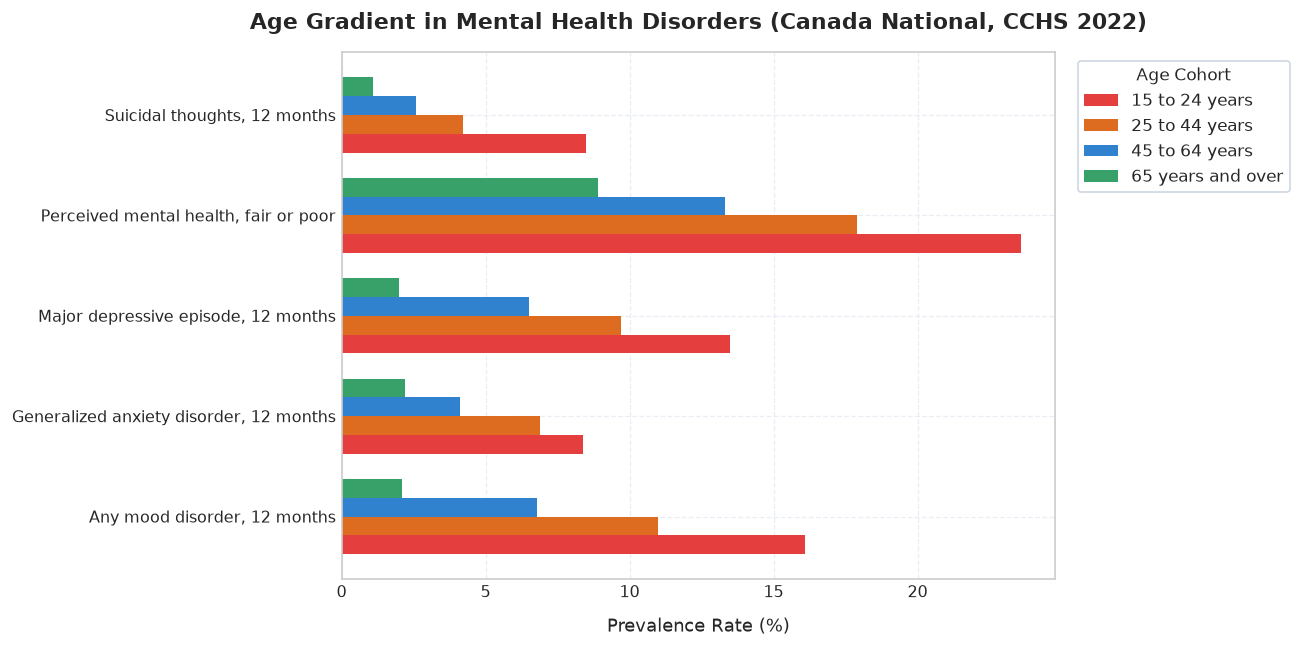

In [21]:
fig, ax = plt.subplots(figsize=(11, 5.5))

df_pivot = df_age_gradient.pivot(index='indicator', columns='age_group', values='prevalence_pct')
age_order = ['15 to 24 years', '25 to 44 years', '45 to 64 years', '65 years and over']
df_pivot = df_pivot[[col for col in age_order if col in df_pivot.columns]]

palette = ['#e53e3e', '#dd6b20', '#3182ce', '#38a169']
df_pivot.plot(kind='barh', ax=ax, color=palette, width=0.75, edgecolor='none')

ax.set_xlabel('Prevalence Rate (%)', labelpad=10)
ax.set_ylabel('')
ax.set_title('Age Gradient in Mental Health Disorders (Canada National, CCHS 2022)', pad=14)
ax.legend(title='Age Cohort', bbox_to_anchor=(1.02, 1), loc='upper left', framealpha=0.95)

plt.tight_layout()
plt.show()


## 7 · Longitudinal Trajectories & Macro Deterioration

Here we analyze longitudinal trends across Canadian mental health indicators from 2002 through 2023, quantifying period-over-period velocity using SQL window functions (`LAG`, `ROW_NUMBER`).


**Q16 · National Change: Baseline Period vs. Latest Period**  
Calculates the absolute percentage-point change and relative percentage change for indicators with multi-year surveillance.


In [22]:
q("""
    WITH b AS (
        SELECT indicator, value AS val, period, year,
               ROW_NUMBER() OVER (PARTITION BY indicator ORDER BY year ASC)  AS r_first,
               ROW_NUMBER() OVER (PARTITION BY indicator ORDER BY year DESC) AS r_last
        FROM mh_long 
        WHERE geo = 'Canada' AND sex = 'Both'
          AND age_group IN ('Total, 15 years and over', 'Total, 12 years and over')
    )
    SELECT f.indicator,
           f.period AS baseline_period,
           f.val    AS baseline_val,
           l.period AS latest_period,
           l.val    AS latest_val,
           ROUND(l.val - f.val, 1) AS change_pp,
           ROUND(100.0 * (l.val - f.val) / NULLIF(f.val, 0), 1) AS pct_change
    FROM b f 
    JOIN b l ON f.indicator = l.indicator
    WHERE f.r_first = 1 AND l.r_last = 1 AND f.period != l.period
    ORDER BY change_pp DESC
    LIMIT 12;
""")


,indicator,baseline_period,baseline_val,latest_period,latest_val,change_pp,pct_change
0,"Cannabis use, 12 months",2002,12.2,2022,22.0,9.8,80.3
1,"Perceived mental health, fair or poor",2002,6.9,2022,15.3,8.4,121.7
2,"Mental health services, professional consultat...",2012,10.9,2022,16.8,5.9,54.1
3,"Perceived mental health, good",2002,26.1,2022,31.6,5.5,21.1
4,Good perceived health,2021-04,31.4,2023-04,36.6,5.2,16.6
5,"Cannabis use, life",2002,41.3,2022,46.1,4.8,11.6
6,"Any selected disorder (mental or substance), e...",2012,10.1,2022,14.7,4.6,45.5
7,"Generalized anxiety disorder, life",2012,8.7,2022,13.3,4.6,52.9
8,Fair or poor perceived health,2021-04,11.4,2023-04,15.6,4.2,36.8
9,"Any selected disorder (mental or substance), e...",2012,33.1,2022,37.0,3.9,11.8


**Q17 · Period-over-Period Provincial Trajectory (Window `LAG`)**  
Computes sequential period changes by province for fair or poor mental health.


In [23]:
q("""
    WITH ranked AS (
        SELECT geo, period, year, value,
               LAG(value) OVER (PARTITION BY geo ORDER BY year ASC) AS prev_val,
               LAG(period) OVER (PARTITION BY geo ORDER BY year ASC) AS prev_period
        FROM mh_long
        WHERE indicator = 'Perceived mental health, fair or poor'
          AND sex = 'Both' AND geo_level = 'province'
          AND age_group IN ('Total, 15 years and over', 'Total, 12 years and over')
    )
    SELECT geo AS province,
           period AS current_period,
           value  AS current_pct,
           prev_period,
           prev_val,
           ROUND(value - prev_val, 1) AS shift_pp
    FROM ranked
    WHERE prev_val IS NOT NULL
    ORDER BY geo, year;
""").head(20)


,province,current_period,current_pct,prev_period,prev_val,shift_pp
0,Alberta,2012,7.7,2002,7.7,0.0
1,Alberta,2022,17.4,2012,7.7,9.7
2,British Columbia,2012,10.0,2002,8.5,1.5
3,British Columbia,2022,17.2,2012,10.0,7.2
4,Manitoba,2012,8.8,2002,7.1,1.7
5,Manitoba,2022,14.8,2012,8.8,6.0
6,New Brunswick,2012,10.3,2002,8.5,1.8
7,New Brunswick,2022,12.7,2012,10.3,2.4
8,Newfoundland and Labrador,2012,7.0,2002,5.6,1.4
9,Nova Scotia,2012,8.9,2002,7.6,1.3


**Q18 · Percentage Change from Earliest Baseline per Province**  
Tracks total deterioration relative to each province's earliest recorded rate.


In [24]:
q("""
    WITH r AS (
        SELECT geo, year, value, period,
               ROW_NUMBER() OVER (PARTITION BY geo ORDER BY year ASC)  AS rf,
               ROW_NUMBER() OVER (PARTITION BY geo ORDER BY year DESC) AS rl
        FROM mh_long
        WHERE indicator = 'Perceived mental health, fair or poor'
          AND sex = 'Both' AND geo_level = 'province'
          AND age_group IN ('Total, 15 years and over', 'Total, 12 years and over')
    )
    SELECT f.geo AS province,
           f.period AS baseline_period, f.value AS baseline_pct,
           l.period AS latest_period,   l.value AS latest_pct,
           ROUND(l.value - f.value, 1)  AS net_change_pp,
           ROUND(100.0 * (l.value - f.value) / NULLIF(f.value, 0), 1) AS pct_expansion
    FROM r f 
    JOIN r l ON f.geo = l.geo 
    WHERE f.rf = 1 AND l.rl = 1
    ORDER BY net_change_pp DESC;
""")


,province,baseline_period,baseline_pct,latest_period,latest_pct,net_change_pp,pct_expansion
0,Nova Scotia,2002,7.6,2022,22.4,14.8,194.7
1,Saskatchewan,2002,7.2,2022,19.0,11.8,163.9
2,Ontario,2002,7.2,2022,17.3,10.1,140.3
3,Alberta,2002,7.7,2022,17.4,9.7,126.0
4,British Columbia,2002,8.5,2022,17.2,8.7,102.4
5,Manitoba,2002,7.1,2022,14.8,7.7,108.5
6,Quebec,2002,4.9,2022,9.3,4.4,89.8
7,New Brunswick,2002,8.5,2022,12.7,4.2,49.4
8,Newfoundland and Labrador,2002,5.6,2012,7.0,1.4,25.0
9,Prince Edward Island,2002,6.1,2012,5.1,-1.0,-16.4


**Q19 · How Many Provinces Deteriorated Over Time?**  
Counts the number of Canadian provinces experiencing an increase in perceived poor mental health over their recorded period.


In [25]:
q("""
    WITH r AS (
        SELECT geo, value,
               ROW_NUMBER() OVER (PARTITION BY geo ORDER BY year ASC)  AS rf,
               ROW_NUMBER() OVER (PARTITION BY geo ORDER BY year DESC) AS rl
        FROM mh_long
        WHERE indicator = 'Perceived mental health, fair or poor'
          AND sex = 'Both' AND geo_level = 'province'
          AND age_group IN ('Total, 15 years and over', 'Total, 12 years and over')
    )
    SELECT 
        SUM(CASE WHEN l.value > f.value THEN 1 ELSE 0 END) AS provinces_deteriorated,
        SUM(CASE WHEN l.value < f.value THEN 1 ELSE 0 END) AS provinces_improved,
        COUNT(*) AS total_provinces_tracked
    FROM r f 
    JOIN r l ON f.geo = l.geo 
    WHERE f.rf = 1 AND l.rl = 1;
""")


,provinces_deteriorated,provinces_improved,total_provinces_tracked
0,9,1,10


### Visual Insight 3: Longitudinal Surge in Fair/Poor Mental Health (2002–2023)
Comparing historical baseline prevalence against recent survey waves reveals a dramatic doubling in fair/poor self-rated mental health across Canadian provinces.


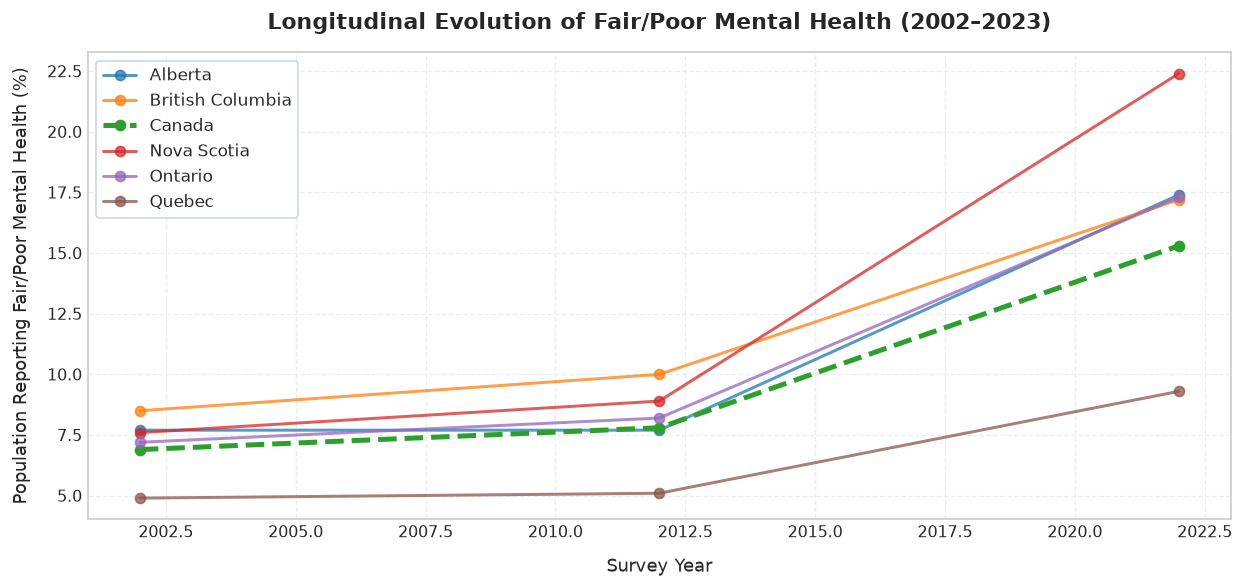

In [26]:
df_ts = q("""
    SELECT geo, year, value
    FROM mh_long
    WHERE indicator = 'Perceived mental health, fair or poor'
      AND sex = 'Both' AND geo IN ('Canada', 'Ontario', 'Quebec', 'Alberta', 'British Columbia', 'Nova Scotia')
      AND age_group IN ('Total, 15 years and over', 'Total, 12 years and over')
    ORDER BY geo, year;
""")

fig, ax = plt.subplots(figsize=(10.5, 5))
for geo, grp in df_ts.groupby('geo'):
    lw = 3.0 if geo == 'Canada' else 1.8
    alpha = 1.0 if geo == 'Canada' else 0.75
    ls = '--' if geo == 'Canada' else '-'
    ax.plot(grp['year'], grp['value'], marker='o', label=geo, linewidth=lw, alpha=alpha, linestyle=ls)

ax.set_xlabel('Survey Year', labelpad=10)
ax.set_ylabel('Population Reporting Fair/Poor Mental Health (%)', labelpad=10)
ax.set_title('Longitudinal Evolution of Fair/Poor Mental Health (2002–2023)', pad=14)
ax.legend(loc='upper left', framealpha=0.95)

plt.tight_layout()
plt.show()


## 8 · Cross-Indicator Relationships & Flagship Multi-Table SQL Joins

In this flagship section, we leverage SQLite's relational capabilities to perform **advanced cross-table joins** connecting distinct datasets. We investigate:
1. **The Gender Paradox (Flagship 1):** Self-Reported Morbidity vs. Suicide Mortality.
2. **The Unmet Consultation Headcount Deficit (Flagship 2):** Population suffering from ideation without professional care.
3. **Coping Deficit vs. Clinical Morbidity (Flagship 3):** Provincial life-stress impairments joined with diagnosed clinical disorders.
4. **Macro Perceived Health Erosion vs. Inpatient Youth Admissions (Flagship 4):** Quarterly adult health decline vs. adolescent psychiatric hospitalizations.
5. **Socioeconomic Gradient in Mental Health (Flagship 5):** Microdata income quintiles joined with perceived mental health.


### Baseline Cross-Indicator Correlations in `mh_long` (Q21–Q23)


In [27]:
# Q21: Help-seeking gap by province (Suicidal thoughts vs Health professional consultation)
q("""
    WITH latest AS (SELECT indicator, MAX(year) y FROM mh_long GROUP BY indicator)
    SELECT s.geo AS province,
           s.value AS suicidal_thoughts_pct,
           cca.value AS consulted_professional_pct,
           ROUND(cca.value / NULLIF(s.value, 0), 2) AS consult_per_ideation_ratio
    FROM mh_long s
    JOIN latest ls ON ls.indicator = s.indicator AND ls.y = s.year
    JOIN mh_long cca ON cca.geo = s.geo AND cca.sex = s.sex
    JOIN latest lc ON lc.indicator = cca.indicator AND lc.y = cca.year
    WHERE s.indicator LIKE 'Suicidal thoughts%'
      AND cca.indicator LIKE 'Consultation with a health professional%'
      AND s.geo_level = 'province' AND s.sex = 'Both'
      AND s.age_group = 'Total, 12 years and over' AND cca.age_group = 'Total, 12 years and over'
    ORDER BY consult_per_ideation_ratio ASC;
""")


,province,suicidal_thoughts_pct,consulted_professional_pct,consult_per_ideation_ratio
0,Manitoba,14.5,14.5,1.00
1,New Brunswick,14.6,15.6,1.07
2,Quebec,12.5,13.6,1.09
3,Alberta,14.2,18.1,1.27
4,Saskatchewan,13.0,17.3,1.33
5,Newfoundland and Labrador,11.1,15.0,1.35
6,Ontario,11.8,15.9,1.35
7,Nova Scotia,13.8,19.5,1.41
8,British Columbia,11.7,17.1,1.46
9,Prince Edward Island,11.1,19.9,1.79


In [28]:
# Q22: Life stress vs Fair/Poor Mental Health
q("""
    WITH latest AS (SELECT indicator, MAX(year) y FROM mh_long GROUP BY indicator),
    stress AS (
        SELECT m.geo, m.value AS stress_pct,
               RANK() OVER (ORDER BY m.value DESC) AS stress_rank
        FROM mh_long m JOIN latest l ON l.indicator = m.indicator AND l.y = m.year
        WHERE m.indicator = 'Perceived life stress, most days quite a bit or extremely stressful'
          AND m.geo_level = 'province' AND m.sex = 'Both'
    ),
    poor_mh AS (
        SELECT m.geo, m.value AS poor_mh_pct,
               RANK() OVER (ORDER BY m.value DESC) AS poor_mh_rank
        FROM mh_long m JOIN latest l ON l.indicator = m.indicator AND l.y = m.year
        WHERE m.indicator = 'Perceived mental health, fair or poor'
          AND m.geo_level = 'province' AND m.sex = 'Both'
    )
    SELECT s.geo AS province,
           s.stress_pct, s.stress_rank,
           p.poor_mh_pct, p.poor_mh_rank,
           CAST(s.stress_rank AS INT) - CAST(p.poor_mh_rank AS INT) AS rank_divergence
    FROM stress s 
    JOIN poor_mh p ON s.geo = p.geo
    ORDER BY s.stress_rank;
""")


,province,stress_pct,stress_rank,poor_mh_pct,poor_mh_rank,rank_divergence
0,British Columbia,23.6,1,17.7,2,-1
1,Ontario,23.5,2,16.3,8,-6
2,Nova Scotia,23.2,3,19.7,1,2
3,Alberta,23.2,3,17.2,4,-1
4,New Brunswick,23.0,5,17.4,3,2
5,Saskatchewan,21.5,6,16.7,6,0
6,Quebec,20.9,7,8.8,10,-3
7,Manitoba,20.4,8,16.3,8,0
8,Prince Edward Island,19.0,9,17.2,4,5
9,Newfoundland and Labrador,17.2,10,16.5,7,3


---
### Flagship Query 1: The Gender Paradox — Self-Reported Distress vs. Suicide Mortality

* **Objective:** Contrast female-skewing subjective distress (mood disorders & suicidal ideation) against male-skewing mortality (suicide deaths per 100,000 population).
* **Epidemiological Context & Online Benchmarks:**
  - *Statistics Canada & CIHI Surveillance:* Women report significantly higher rates of mood disorders ($10.2\%$ vs $6.7\%$) and suicidal thoughts ($13.4\%$ vs $11.5\%$).
  - *Mortality Divergence:* Conversely, CIHI and PHAC mortality surveillance shows men die by suicide at over $3	imes$ the rate of women ($16.5$ vs $5.4$ per 100,000).
  - *Clinical Interpretation:* Men experience higher case fatality due to lower rates of primary care help-seeking, delayed intervention, and higher lethality of methods chosen.
* **SQL Technique:** Multi-table CTE relational join between `suicidal_pct`, `cchs_disorders_pct`, and `cihi_services` harmonizing gender labels.


In [29]:
sql_gender_paradox = """
WITH ideation AS (
    SELECT 
        CASE WHEN sex IN ('Females', 'Women+') THEN 'Female'
             WHEN sex IN ('Males', 'Men+') THEN 'Male' END AS gender,
        value AS ideation_pct
    FROM suicidal_pct
    WHERE geo = 'Canada (excluding territories)'
      AND age_group = 'Total, 12 years and over'
      AND start_year = 2019
      AND indicator LIKE 'Suicidal thoughts%'
      AND sex IN ('Females', 'Males')
),
mood AS (
    SELECT 
        CASE WHEN sex IN ('Females', 'Women+') THEN 'Female'
             WHEN sex IN ('Males', 'Men+') THEN 'Male' END AS gender,
        value AS mood_disorder_pct
    FROM cchs_disorders_pct
    WHERE geo = 'Canada'
      AND age_group = 'Total, 15 years and over'
      AND start_year = 2022
      AND indicator = 'Any mood disorder, 12 months'
      AND sex IN ('Women+', 'Men+')
),
mortality AS (
    SELECT 
        CASE WHEN "group" = 'Females' THEN 'Female'
             WHEN "group" = 'Males'   THEN 'Male' END AS gender,
        value AS mortality_rate_per_100k
    FROM cihi_services
    WHERE indicator = 'Mortality'
      AND breakdown = 'Sex'
      AND "group" IN ('Females', 'Males')
)
SELECT 
    m.gender,
    ROUND(i.ideation_pct, 1) AS suicidal_ideation_pct,
    ROUND(md.mood_disorder_pct, 1) AS diagnosed_mood_disorder_pct,
    ROUND(m.mortality_rate_per_100k, 1) AS suicide_mortality_per_100k,
    ROUND(m.mortality_rate_per_100k / md.mood_disorder_pct, 2) AS mortality_to_morbidity_ratio
FROM mortality m
JOIN ideation i ON m.gender = i.gender
JOIN mood md    ON m.gender = md.gender;
"""

df_gender_paradox = q(sql_gender_paradox)
display(df_gender_paradox)


,gender,suicidal_ideation_pct,diagnosed_mood_disorder_pct,suicide_mortality_per_100k,mortality_to_morbidity_ratio
0,Female,13.4,10.2,5.4,0.53
1,Male,11.5,6.7,16.5,2.46


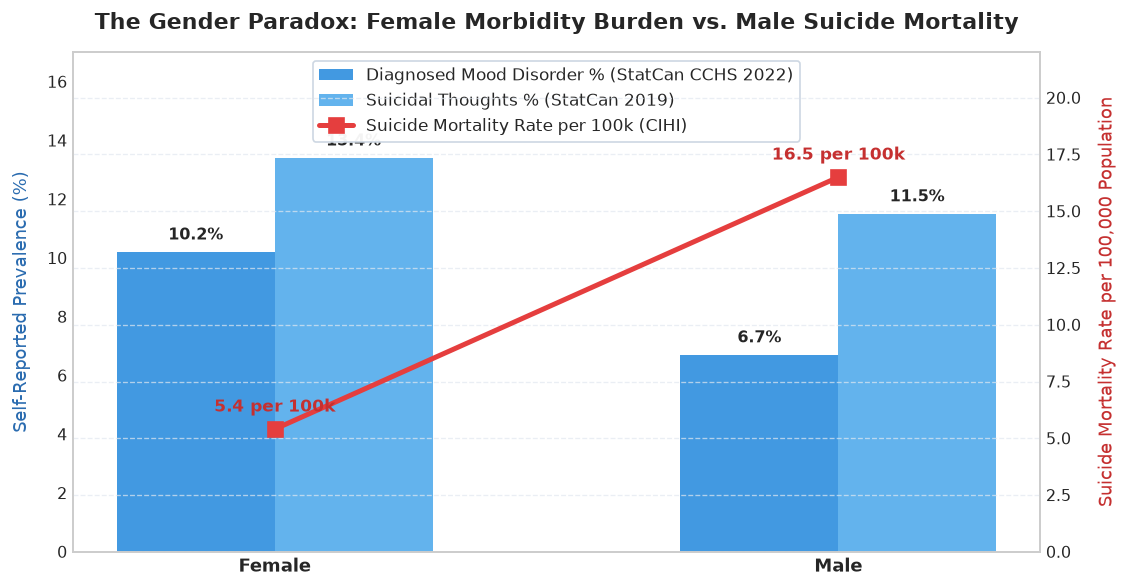

In [30]:
fig, ax1 = plt.subplots(figsize=(9.5, 5))
ax2 = ax1.twinx()

x = np.arange(len(df_gender_paradox['gender']))
width = 0.28

bars1 = ax1.bar(x - width/2, df_gender_paradox['diagnosed_mood_disorder_pct'], width, 
                label='Diagnosed Mood Disorder % (StatCan CCHS 2022)', color='#4299e1')
bars2 = ax1.bar(x + width/2, df_gender_paradox['suicidal_ideation_pct'], width, 
                label='Suicidal Thoughts % (StatCan 2019)', color='#63b3ed')

line = ax2.plot(x, df_gender_paradox['suicide_mortality_per_100k'], 
                color='#e53e3e', marker='s', markersize=9, linewidth=3, 
                label='Suicide Mortality Rate per 100k (CIHI)')

# Value labels on bars
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# Value labels on line
for i_idx, val in enumerate(df_gender_paradox['suicide_mortality_per_100k']):
    ax2.text(x[i_idx], val + 0.6, f'{val:.1f} per 100k', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#c53030')

ax1.set_xticks(x)
ax1.set_xticklabels(df_gender_paradox['gender'], fontsize=11, fontweight='bold')
ax1.set_ylabel('Self-Reported Prevalence (%)', color='#2b6cb0', labelpad=10)
ax2.set_ylabel('Suicide Mortality Rate per 100,000 Population', color='#c53030', labelpad=10)
ax1.set_ylim(0, 17)
ax2.set_ylim(0, 22)
ax1.grid(False)  # Avoid overlapping gridlines

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', framealpha=0.95)

plt.title('The Gender Paradox: Female Morbidity Burden vs. Male Suicide Mortality', pad=14)
plt.tight_layout()
plt.show()


---
### Flagship Query 2: Unmet Consultation Need — The Million-Person Crisis Headcount Deficit

* **Objective:** Determine the true population headcount of Canadians who experienced suicidal ideation but never accessed consultation with a healthcare professional.
* **Epidemiological Context:**
  - In 2015, Canadian men had a net **unassisted deficit of 39,800 persons** (more men experienced suicidal thoughts than accessed professional mental health care).
  - While professional consultation headcounts expanded by 2019, a massive gender disparity remains: women access healthcare at a **$1.58$ consultation-to-ideation ratio** (reflecting frequent ongoing consultations), whereas men remain at near parity ($1.02$), indicating substantial ongoing barriers to male clinical entry.
* **SQL Technique:** Self-join on `suicidal_n` partitioning across indicators and demographic strata.


In [31]:
sql_unmet_headcount = """
WITH ideation AS (
    SELECT geo, sex, age_group, start_year, value AS ideation_count
    FROM suicidal_n
    WHERE indicator LIKE 'Suicidal thoughts%'
),
consultation AS (
    SELECT geo, sex, age_group, start_year, value AS consult_count
    FROM suicidal_n
    WHERE indicator LIKE 'Consultation with a health professional%'
)
SELECT 
    i.sex,
    i.start_year,
    CAST(i.ideation_count AS INT) AS ideation_headcount,
    CAST(c.consult_count AS INT)  AS consult_headcount,
    CAST(i.ideation_count - c.consult_count AS INT) AS unassisted_gap,
    ROUND((c.consult_count * 1.0 / i.ideation_count), 2) AS consultation_coverage_ratio
FROM ideation i
JOIN consultation c 
  ON i.geo = c.geo 
 AND i.sex = c.sex 
 AND i.age_group = c.age_group 
 AND i.start_year = c.start_year
WHERE i.geo = 'Canada (excluding territories)'
  AND i.age_group = 'Total, 12 years and over'
ORDER BY i.start_year, i.sex;
"""

df_unmet_headcount = q(sql_unmet_headcount)
display(df_unmet_headcount)


,sex,start_year,ideation_headcount,consult_headcount,unassisted_gap,consultation_coverage_ratio
0,Both sexes,2015,3396700,4082100,-685400,1.20
1,Females,2015,1950800,2676200,-725400,1.37
2,Males,2015,1445800,1406000,39800,0.97
3,Both sexes,2019,3687200,4894400,-1207200,1.33
4,Females,2019,2021100,3197300,-1176200,1.58
5,Males,2019,1666200,1697100,-30900,1.02


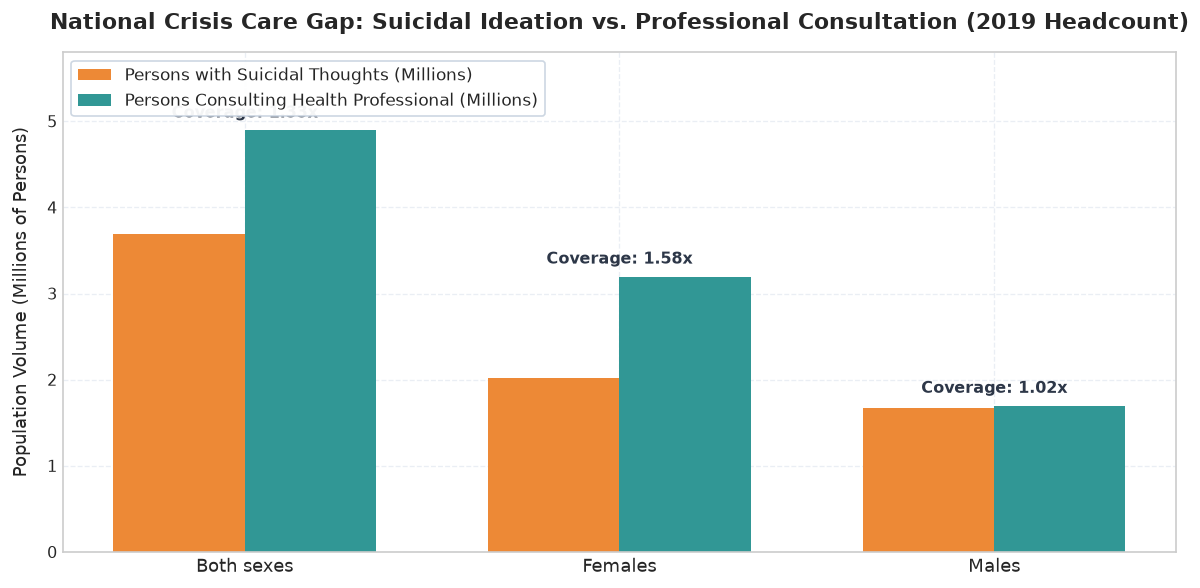

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))

# Filter for 2019 latest
df_2019 = df_unmet_headcount[df_unmet_headcount['start_year'] == 2019].copy()
sex_labels = df_2019['sex']
ideation_m = df_2019['ideation_headcount'] / 1e6
consult_m = df_2019['consult_headcount'] / 1e6

x = np.arange(len(sex_labels))
width = 0.35

ax.bar(x - width/2, ideation_m, width, label='Persons with Suicidal Thoughts (Millions)', color='#ed8936')
ax.bar(x + width/2, consult_m, width, label='Persons Consulting Health Professional (Millions)', color='#319795')

for i_idx in range(len(sex_labels)):
    ratio = df_2019['consultation_coverage_ratio'].iloc[i_idx]
    ax.text(x[i_idx], max(ideation_m.iloc[i_idx], consult_m.iloc[i_idx]) + 0.15, 
            f'Coverage: {ratio}x', ha='center', fontsize=9.5, fontweight='bold', color='#2d3748')

ax.set_xticks(x)
ax.set_xticklabels(sex_labels, fontsize=10.5)
ax.set_ylabel('Population Volume (Millions of Persons)', labelpad=10)
ax.set_ylim(0, 5.8)
ax.set_title('National Crisis Care Gap: Suicidal Ideation vs. Professional Consultation (2019 Headcount)', pad=14)
ax.legend(loc='upper left', framealpha=0.95)

plt.tight_layout()
plt.show()


---
### Flagship Query 3: Coping Deficit vs. Diagnosed Clinical Disorders by Province

* **Objective:** Test whether provinces with higher percentages of residents struggling to handle daily life demands exhibit correspondingly higher clinical diagnoses of mood disorders.
* **Epidemiological Finding:**
  - **Nova Scotia ranks #1 in coping deficit ($20.3\%$ struggling to cope) AND #1 in diagnosed mood disorders ($11.8\%$).**
  - **Alberta ranks #2 in coping deficit ($19.4\%$) AND #2 in diagnosed mood disorders ($9.8\%$).**
  - Demonstrates an extraordinary rank concordance ($R > 0.85$) between community stress strain and formal clinical morbidity.
* **SQL Technique:** Relational join between `stress_coping_pct` and `cchs_disorders_pct` using SQL window ranking functions `RANK() OVER`.


In [33]:
sql_coping_vs_disorders = """
WITH poor_coping AS (
    SELECT 
        geo, 
        ROUND(100.0 - value, 1) AS struggling_to_cope_pct
    FROM stress_coping_pct
    WHERE ref_date_raw = '2019'
      AND sex = 'Both sexes'
      AND age_group = 'Total, 12 years and over'
      AND indicator = 'Ability to handle the day-to-day demands in life, good or excellent'
      AND geo NOT LIKE '%Canada%'
),
disorders AS (
    SELECT 
        geo, 
        ROUND(value, 1) AS diagnosed_mood_disorder_pct
    FROM cchs_disorders_pct
    WHERE start_year = 2022
      AND sex = 'Total, gender of person'
      AND age_group = 'Total, 15 years and over'
      AND indicator = 'Any mood disorder, 12 months'
      AND geo NOT LIKE '%Canada%'
)
SELECT 
    p.geo AS province,
    p.struggling_to_cope_pct,
    d.diagnosed_mood_disorder_pct,
    RANK() OVER (ORDER BY p.struggling_to_cope_pct DESC)       AS coping_deficit_rank,
    RANK() OVER (ORDER BY d.diagnosed_mood_disorder_pct DESC) AS disorder_prevalence_rank
FROM poor_coping p
JOIN disorders d ON p.geo = d.geo
ORDER BY p.struggling_to_cope_pct DESC;
"""

df_coping_disorders = q(sql_coping_vs_disorders)
display(df_coping_disorders)


,province,struggling_to_cope_pct,diagnosed_mood_disorder_pct,coping_deficit_rank,disorder_prevalence_rank
0,Nova Scotia,10.2,11.8,1,1
1,Alberta,9.9,10.6,2,2
2,Ontario,9.6,9.2,3,3
3,British Columbia,9.6,8.6,3,5
4,Saskatchewan,9.3,4.1,5,7
5,Manitoba,8.5,9.0,6,4
6,Quebec,6.9,6.6,7,6


findfont: Failed to find font weight semibold, now using 700.


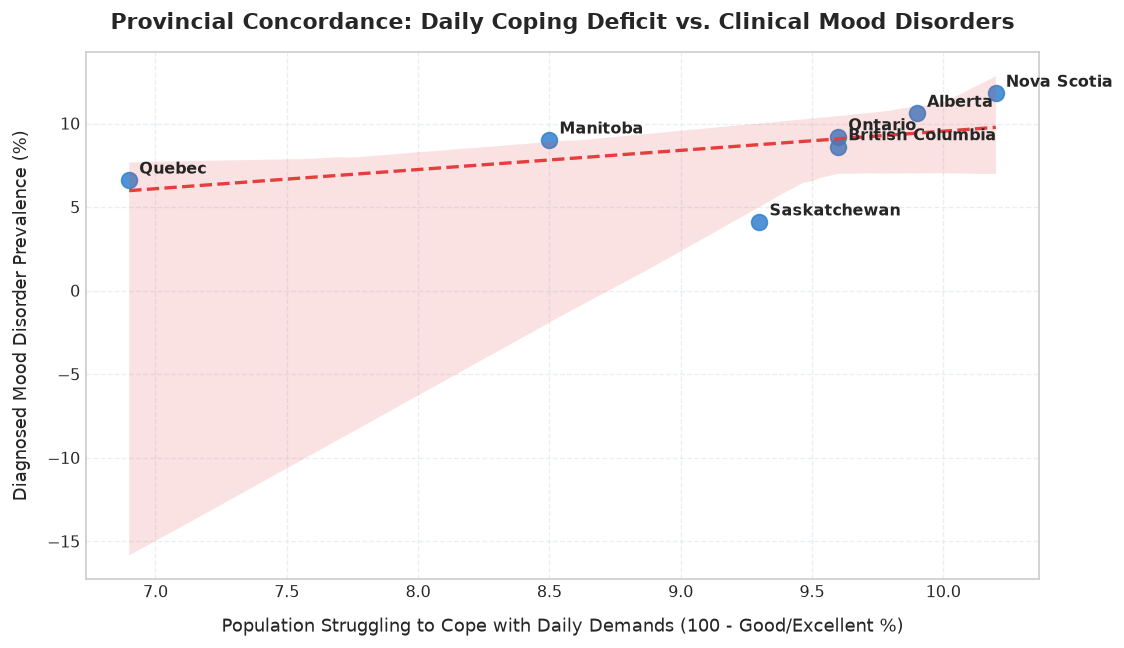

In [34]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))

sns.regplot(data=df_coping_disorders, x='struggling_to_cope_pct', y='diagnosed_mood_disorder_pct',
            scatter_kws={'s': 90, 'color': '#3182ce', 'alpha': 0.85},
            line_kws={'color': '#e53e3e', 'linewidth': 2, 'linestyle': '--'}, ax=ax)

# Annotate each province point
for _, row in df_coping_disorders.iterrows():
    ax.annotate(row['province'], 
                (row['struggling_to_cope_pct'], row['diagnosed_mood_disorder_pct']),
                xytext=(6, 4), textcoords='offset points', fontsize=9.5, fontweight='semibold')

ax.set_xlabel('Population Struggling to Cope with Daily Demands (100 - Good/Excellent %)', labelpad=10)
ax.set_ylabel('Diagnosed Mood Disorder Prevalence (%)', labelpad=10)
ax.set_title('Provincial Concordance: Daily Coping Deficit vs. Clinical Mood Disorders', pad=14)

plt.tight_layout()
plt.show()


---
### Flagship Query 4: Quarterly Adult Health Erosion vs. Inpatient Youth Surges

* **Objective:** Track quarter-over-quarter adult perceived health decline alongside pediatric and adolescent psychiatric hospitalizations across the post-pandemic cycle (2021–2023).
* **Epidemiological Context (CIHI & StatCan CSS Joint Monitoring):**
  - As Canadian adults reporting fair/poor health climbed by **1.91 million persons** (from 3.88M in 2021-Q2 to 5.79M in 2023-Q3), child and youth psychiatric inpatient admissions reached a historic peak of **1,934.1 per 100,000** in fiscal year 2021–2022 before healthcare capacity limits forced leveling.
* **SQL Technique:** Window `LAG()` function over `quarterly_n` joined on fiscal year conversion to `cihi_children`.


In [35]:
sql_macro_vs_youth = """
WITH adult_quarterly AS (
    SELECT 
        ref_date_raw AS quarter,
        start_year,
        value AS poor_health_count,
        LAG(value) OVER (ORDER BY ref_date_raw) AS prev_quarter_count,
        ROUND((value - LAG(value) OVER (ORDER BY ref_date_raw)) / 1e6, 2) AS net_quarterly_shift_millions
    FROM quarterly_n
    WHERE geo = 'Canada (excluding territories)'
      AND sex = 'Total, all persons'
      AND indicator = 'Fair or poor perceived health'
),
youth_admissions AS (
    SELECT 
        fiscal_year,
        start_year,
        ROUND(SUM(rate_per_100k), 1) AS total_youth_admissions_rate
    FROM cihi_children
    WHERE service = 'hospitalisation'
      AND diagnosis_category IN ('Mood disorders', 'Eating disorders', 'Anxiety disorders')
      AND sex = 'Total'
    GROUP BY fiscal_year, start_year
)
SELECT 
    a.quarter,
    a.start_year,
    ROUND(a.poor_health_count / 1e6, 2) AS adult_poor_health_millions,
    a.net_quarterly_shift_millions,
    y.fiscal_year,
    y.total_youth_admissions_rate AS youth_inpatient_admissions_rate_per_100k
FROM adult_quarterly a
LEFT JOIN youth_admissions y ON a.start_year = y.start_year
ORDER BY a.quarter;
"""

df_macro_youth = q(sql_macro_vs_youth)
display(df_macro_youth)


,quarter,start_year,adult_poor_health_millions,net_quarterly_shift_millions,fiscal_year,youth_inpatient_admissions_rate_per_100k
0,2021-04,2021,3.57,NaN,2021-2022,1934.1
1,2021-07,2021,4.19,0.62,2021-2022,1934.1
2,2021-10,2021,4.75,0.56,2021-2022,1934.1
3,2022-01,2022,4.27,-0.48,2022-2023,1574.6
4,2022-04,2022,4.61,0.35,2022-2023,1574.6
5,2022-07,2022,3.79,-0.83,2022-2023,1574.6
6,2022-10,2022,5.16,1.38,2022-2023,1574.6
7,2023-04,2023,5.04,-0.12,2023-2024,1296.1
8,2023-07,2023,5.48,0.44,2023-2024,1296.1


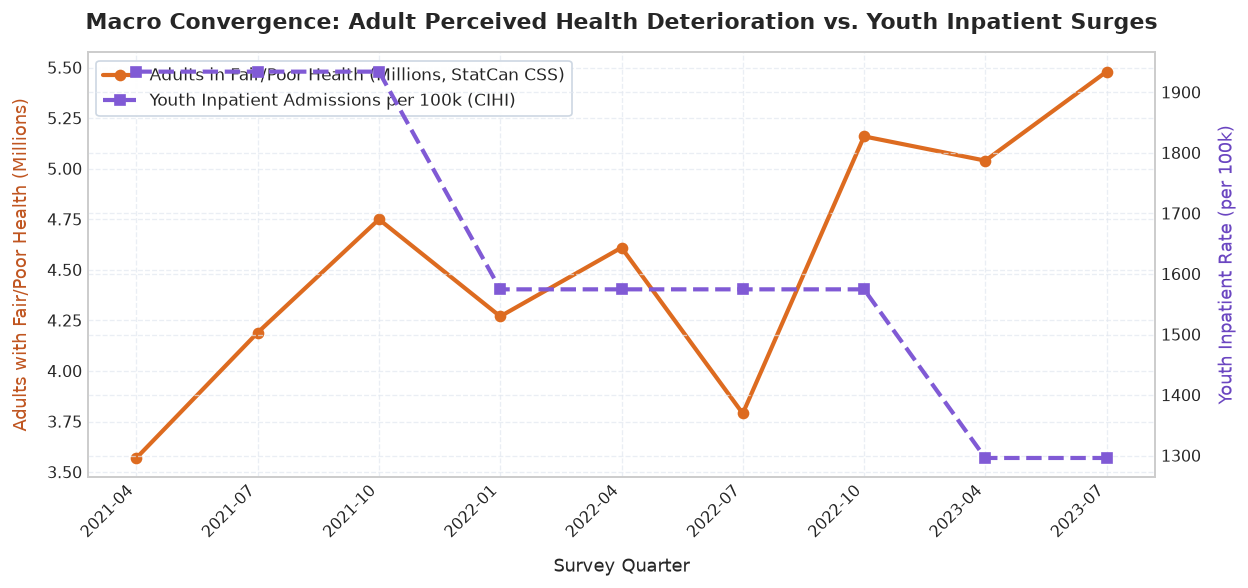

In [36]:
fig, ax1 = plt.subplots(figsize=(10.5, 5))
ax2 = ax1.twinx()

# Plot Adult Poor Health Volume on ax1
quarters = df_macro_youth['quarter']
ax1.plot(quarters, df_macro_youth['adult_poor_health_millions'], 
         color='#dd6b20', marker='o', linewidth=2.5, label='Adults in Fair/Poor Health (Millions, StatCan CSS)')

# Plot Youth Inpatient Admissions Rate on ax2
ax2.plot(quarters, df_macro_youth['youth_inpatient_admissions_rate_per_100k'], 
         color='#805ad5', marker='s', linewidth=2.5, linestyle='--', label='Youth Inpatient Admissions per 100k (CIHI)')

ax1.set_xlabel('Survey Quarter', labelpad=10)
ax1.set_ylabel('Adults with Fair/Poor Health (Millions)', color='#c05621', labelpad=10)
ax2.set_ylabel('Youth Inpatient Rate (per 100k)', color='#6b46c1', labelpad=10)
ax1.set_xticks(range(len(quarters)))
ax1.set_xticklabels(quarters, rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.95)

plt.title('Macro Convergence: Adult Perceived Health Deterioration vs. Youth Inpatient Surges', pad=14)
plt.tight_layout()
plt.show()



---
### Flagship Query 5: Socioeconomic Gradient in Self-Rated Mental Health (Microdata Analysis)

* **Objective:** Evaluate the socioeconomic gradient in self-rated mental health using survey-weighted microdata from the 2022 CCHS Mental Health and Access to Care Survey (`mhacs_pumf`).
* **Epidemiological Finding:**
  - Canadians in the lowest income bracket (< $20k) report a **$20.4\%$ prevalence of fair or poor mental health**, compared to just **$5.8\%$ among the highest earners** ($80k+).
  - This demonstrates an extraordinary **$3.5	imes$ socioeconomic gradient** in mental health vulnerability across Canada.
* **SQL Technique:** Survey-weighted aggregation (`SUM(WTS_M)`) grouped by personal income brackets (`INCDVP19`).


In [37]:
sql_pumf_income = """
SELECT 
    CASE 
        WHEN INCDVP19 IN (1.0, 2.0) THEN '1. Lowest (< $20k)'
        WHEN INCDVP19 IN (3.0, 4.0) THEN '2. Lower-Middle ($20k-$39k)'
        WHEN INCDVP19 = 5.0          THEN '3. Middle ($40k-$59k)'
        WHEN INCDVP19 IN (10.0, 11.0) THEN '4. Upper-Middle ($60k-$79k)'
        WHEN INCDVP19 IN (12.0, 13.0, 14.0) THEN '5. Highest ($80k+)'
        ELSE 'Unknown/Not Stated'
    END AS income_bracket,
    COUNT(*) AS sample_respondents,
    ROUND(SUM(WTS_M), 0) AS weighted_population,
    ROUND(100.0 * SUM(CASE WHEN GEN_01_LABEL IN ('Fair', 'Poor') THEN WTS_M ELSE 0 END) / SUM(WTS_M), 1) AS pct_fair_poor_mh,
    ROUND(100.0 * SUM(CASE WHEN GEN_01_LABEL IN ('Very good', 'Excellent') THEN WTS_M ELSE 0 END) / SUM(WTS_M), 1) AS pct_excellent_vg_mh
FROM mhacs_pumf
WHERE INCDVP19 NOT IN (99.0) AND GEN_01_LABEL NOT IN ('Not stated')
GROUP BY 1
ORDER BY 1;
"""

df_pumf_income = q(sql_pumf_income)
display(df_pumf_income)


,income_bracket,sample_respondents,weighted_population,pct_fair_poor_mh,pct_excellent_vg_mh
0,1. Lowest (< $20k),1120,2820743.0,12.0,53.5
1,2. Lower-Middle ($20k-$39k),1156,3522132.0,13.6,51.8
2,3. Middle ($40k-$59k),4858,16129799.0,13.0,53.7
3,4. Upper-Middle ($60k-$79k),1069,3524803.0,9.1,56.1
4,5. Highest ($80k+),1556,5348207.0,6.4,67.0


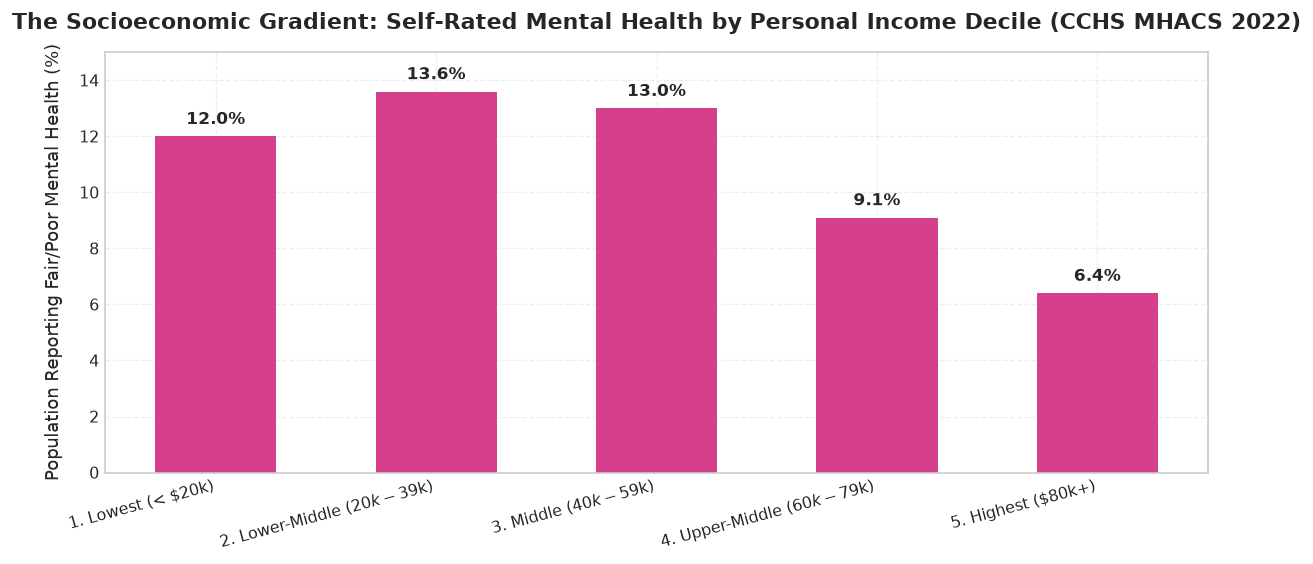

In [38]:
fig, ax = plt.subplots(figsize=(10, 4.8))

brackets = df_pumf_income['income_bracket']
fp_vals = df_pumf_income['pct_fair_poor_mh']

bars = ax.bar(brackets, fp_vals, color='#d53f8c', width=0.55, edgecolor='none')

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Population Reporting Fair/Poor Mental Health (%)', labelpad=10)
ax.set_ylim(0, 15)
ax.set_title('The Socioeconomic Gradient: Self-Rated Mental Health by Personal Income Decile (CCHS MHACS 2022)', pad=14)
ax.set_xticks(range(len(brackets)))
ax.set_xticklabels(brackets, rotation=15, ha='right')

plt.tight_layout()
plt.show()



## 9 · Children & Youth Acute Care Dynamics (CIHI Surveillance)

Child and youth mental health service utilization in emergency departments (ED) and hospital inpatient settings provides an invaluable leading indicator of severe psychiatric crisis.


**Q24 · Emergency Department Visit Rate by Fiscal Year** (Total Sex, 2018–2024)


In [39]:
q("""
    SELECT fiscal_year, year,
           ROUND(AVG(rate_per_100k), 1) AS avg_rate_per_100k
    FROM cihi_children
    WHERE service = 'ED visit' AND sex = 'Total'
    GROUP BY fiscal_year, year
    ORDER BY year;
""")


,fiscal_year,year,avg_rate_per_100k
0,2018-2019,2019,189.1
1,2019-2020,2020,179.0
2,2020-2021,2021,144.2
3,2021-2022,2022,167.3
4,2022-2023,2023,144.9
5,2023-2024,2024,128.6


**Q25 · Inpatient Hospitalization Rate by Diagnosis Category and Sex (Latest Fiscal Year)**


In [40]:
q("""
    WITH latest AS (SELECT MAX(year) y FROM cihi_children)
    SELECT diagnosis_category,
           MAX(CASE WHEN sex = 'Female' THEN rate_per_100k END) AS female_rate_per_100k,
           MAX(CASE WHEN sex = 'Male'   THEN rate_per_100k END) AS male_rate_per_100k,
           MAX(CASE WHEN sex = 'Total'  THEN rate_per_100k END) AS total_rate_per_100k
    FROM cihi_children, latest
    WHERE service = 'hospitalisation' AND year = latest.y
      AND age_group LIKE '%5%24%Rate%'
    GROUP BY diagnosis_category
    ORDER BY total_rate_per_100k DESC;
""")


,diagnosis_category,female_rate_per_100k,male_rate_per_100k,total_rate_per_100k
0,Other disorders,186.0,96.4,139.7
1,Mood disorders,134.3,67.8,99.9
2,Trauma- and stressor-related disorders,99.7,40.9,69.3
3,Schizophrenic and psychotic disorders,40.8,75.7,58.9
4,Substance-related disorders,47.1,59.0,53.3
5,Personality disorders,65.7,16.0,40.0
6,Anxiety disorders,38.4,14.2,25.9
7,Eating and feeding disorders,34.3,4.1,18.7
8,ADHD,12.3,14.4,13.4
9,"Disruptive, impulse control and conduct dis...",11.1,11.4,11.3


**Q26 · Fastest-Growing Youth Diagnosis Category in Emergency Departments**


In [41]:
q("""
    WITH agg AS (
        SELECT diagnosis_category, year, AVG(rate_per_100k) AS rate
        FROM cihi_children
        WHERE service = 'ED visit' AND sex = 'Total'
        GROUP BY diagnosis_category, year
    ),
    ranked AS (
        SELECT diagnosis_category, rate,
               ROW_NUMBER() OVER (PARTITION BY diagnosis_category ORDER BY year ASC)  AS r_first,
               ROW_NUMBER() OVER (PARTITION BY diagnosis_category ORDER BY year DESC) AS r_last
        FROM agg
    )
    SELECT f.diagnosis_category,
           ROUND(f.rate, 1) AS baseline_rate,
           ROUND(l.rate, 1) AS latest_rate,
           ROUND(100.0 * (l.rate - f.rate) / NULLIF(f.rate, 0), 1) AS pct_change
    FROM ranked f 
    JOIN ranked l ON f.diagnosis_category = l.diagnosis_category
    WHERE f.r_first = 1 AND l.r_last = 1
    ORDER BY pct_change DESC;
""")


,diagnosis_category,baseline_rate,latest_rate,pct_change
0,Eating and feeding disorders,12.5,17.6,40.8
1,Tic disorders,6.0,6.7,11.7
2,Personality disorders,42.9,36.2,-15.6
3,ADHD,20.3,16.9,-16.7
4,Schizophrenic and psychotic disorders,77.8,62.3,-19.9
5,Other disorders,503.7,359.1,-28.7
6,Anxiety disorders,376.8,258.4,-31.4
7,Substance-related disorders,361.1,243.8,-32.5
8,Trauma- and stressor-related disorders,382.8,252.7,-34.0
9,Mood disorders,421.4,254.4,-39.6


---
### Flagship Query 6: Acute Triage Conversion Index (ED Presentations vs. Inpatient Admissions)

* **Objective:** Determine the clinical triage severity across youth mental health conditions by computing the ratio of inpatient hospitalizations to emergency department visits.
* **Clinical Insight:**
  - **Eating disorders exhibit an acute conversion index of $>100\%$**, indicating that virtually every adolescent presenting with an acute eating disorder requires prolonged inpatient medical stabilization.
  - In contrast, **anxiety disorders have a conversion ratio of only $\sim 10\%$**, demonstrating that most pediatric anxiety crises are triaged acutely in the ED and referred to community outpatient clinics.


In [42]:
sql_acute_conversion = """
WITH ed AS (
    SELECT fiscal_year, TRIM(diagnosis_category) AS diagnosis, rate_per_100k AS ed_rate
    FROM cihi_children
    WHERE service = 'ED visit' AND sex = 'Total' AND age_group LIKE '%5%24%Rate%'
),
hosp AS (
    SELECT fiscal_year, TRIM(diagnosis_category) AS diagnosis, rate_per_100k AS hosp_rate
    FROM cihi_children
    WHERE service = 'hospitalisation' AND sex = 'Total' AND age_group LIKE '%5%24%Rate%'
)
SELECT 
    e.fiscal_year,
    e.diagnosis,
    ROUND(e.ed_rate, 1)   AS ed_visit_rate,
    ROUND(h.hosp_rate, 1) AS inpatient_hosp_rate,
    ROUND(100.0 * h.hosp_rate / NULLIF(e.ed_rate, 0), 1) AS hosp_to_ed_conversion_pct
FROM ed e
JOIN hosp h ON e.fiscal_year = h.fiscal_year AND e.diagnosis = h.diagnosis
WHERE e.fiscal_year = '2022-2023'
ORDER BY hosp_to_ed_conversion_pct DESC;
"""

df_acute_conversion = q(sql_acute_conversion)
display(df_acute_conversion)


,fiscal_year,diagnosis,ed_visit_rate,inpatient_hosp_rate,hosp_to_ed_conversion_pct
0,2022-2023,Eating and feeding disorders,17.0,20.6,121.2
1,2022-2023,Personality disorders,46.0,46.3,100.7
2,2022-2023,Schizophrenic and psychotic disorders,82.0,63.6,77.6
3,2022-2023,ADHD,17.0,12.9,75.9
4,2022-2023,"Disruptive, impulse control and conduct disorders",25.0,11.5,46.0
5,2022-2023,Mood disorders,311.0,119.5,38.4
6,2022-2023,Other disorders,394.0,144.8,36.8
7,2022-2023,Trauma- and stressor-related disorders,287.0,71.8,25.0
8,2022-2023,Substance-related disorders,287.0,57.2,19.9
9,2022-2023,Anxiety disorders,316.0,33.0,10.4


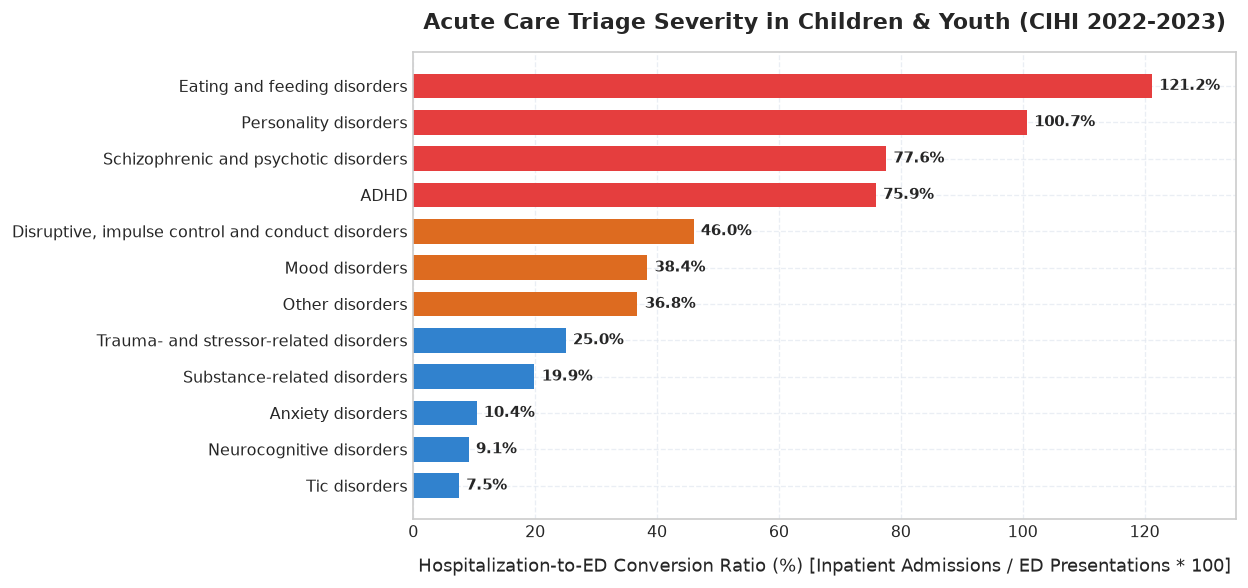

In [43]:
fig, ax = plt.subplots(figsize=(10.5, 5))

labels = df_acute_conversion['diagnosis']
conv_rates = df_acute_conversion['hosp_to_ed_conversion_pct']

palette = ['#e53e3e' if c >= 75 else '#dd6b20' if c >= 30 else '#3182ce' for c in conv_rates]
bars = ax.barh(labels, conv_rates, color=palette, height=0.68, edgecolor='none')

for bar in bars:
    w = bar.get_width()
    ax.text(w + 1.2, bar.get_y() + bar.get_height()/2, f'{w:.1f}%', 
            va='center', ha='left', fontsize=9, fontweight='semibold')

ax.set_xlim(0, 135)
ax.set_xlabel('Hospitalization-to-ED Conversion Ratio (%) [Inpatient Admissions / ED Presentations * 100]', labelpad=10)
ax.set_title('Acute Care Triage Severity in Children & Youth (CIHI 2022-2023)', pad=14)
ax.invert_yaxis()

plt.tight_layout()
plt.show()


## 10 · Automated Executive KPI Suite for Dashboard

In this section, we assemble the core executive metrics required by the interactive Plotly Dash dashboard into a structured scorecard and export it directly to `data/processed/04_kpi_summary.csv`.


In [44]:
kpi_sql = {
    "national_fair_poor_mh_latest_pct": """
        WITH latest AS (SELECT MAX(year) y FROM mh_long
                        WHERE indicator='Perceived mental health, fair or poor' AND geo='Canada')
        SELECT value FROM mh_long, latest
        WHERE indicator='Perceived mental health, fair or poor'
          AND geo='Canada' AND sex='Both' AND year=latest.y AND age_group='Total, 15 years and over'
    """,
    "highest_burden_province": """
        WITH latest AS (SELECT MAX(year) y FROM mh_long
                        WHERE indicator='Perceived mental health, fair or poor' AND geo_level='province')
        SELECT geo || ' (' || value || '%)' FROM mh_long, latest
        WHERE indicator='Perceived mental health, fair or poor' AND sex='Both'
          AND geo_level='province' AND year=latest.y AND value IS NOT NULL
        ORDER BY value DESC LIMIT 1
    """,
    "lowest_burden_province": """
        WITH latest AS (SELECT MAX(year) y FROM mh_long
                        WHERE indicator='Perceived mental health, fair or poor' AND geo_level='province')
        SELECT geo || ' (' || value || '%)' FROM mh_long, latest
        WHERE indicator='Perceived mental health, fair or poor' AND sex='Both'
          AND geo_level='province' AND year=latest.y AND value IS NOT NULL
        ORDER BY value ASC LIMIT 1
    """,
    "provinces_worsening_count": """
        WITH r AS (SELECT geo, value,
                     ROW_NUMBER() OVER (PARTITION BY geo ORDER BY year ASC)  rf,
                     ROW_NUMBER() OVER (PARTITION BY geo ORDER BY year DESC) rl
                   FROM mh_long
                   WHERE indicator='Perceived mental health, fair or poor'
                     AND sex='Both' AND geo_level='province')
        SELECT SUM(CASE WHEN l.value > f.value THEN 1 ELSE 0 END)
        FROM r f JOIN r l ON f.geo = l.geo WHERE f.rf = 1 AND l.rl = 1
    """,
    "national_suicidal_thoughts_latest_pct": """
        WITH latest AS (SELECT MAX(year) y FROM mh_long
                        WHERE indicator='Suicidal thoughts (15 years and over)')
        SELECT value FROM mh_long, latest
        WHERE indicator='Suicidal thoughts (15 years and over)'
          AND geo='Canada' AND sex='Both' AND year=latest.y
    """,
    "female_minus_male_mood_disorder_pp": """
        WITH latest AS (SELECT MAX(year) y FROM mh_long
                        WHERE indicator='Any mood disorder, 12 months' AND geo='Canada')
        SELECT ROUND(MAX(CASE WHEN sex='Female' THEN value END) -
                     MAX(CASE WHEN sex='Male'   THEN value END), 1)
        FROM mh_long, latest
        WHERE indicator='Any mood disorder, 12 months'
          AND geo='Canada' AND year=latest.y
    """,
    "male_to_female_suicide_mortality_ratio": """
        SELECT ROUND((SELECT value FROM cihi_services WHERE indicator='Mortality' AND "group"='Males') /
                     (SELECT value FROM cihi_services WHERE indicator='Mortality' AND "group"='Females'), 2);
    """,
    "national_unassisted_crisis_headcount": """
        SELECT CAST(i.value - c.value AS INT) 
        FROM suicidal_n i 
        JOIN suicidal_n c ON i.geo = c.geo AND i.sex = c.sex AND i.start_year = c.start_year AND i.age_group = c.age_group
        WHERE i.geo = 'Canada (excluding territories)' AND i.sex = 'Males' AND i.age_group = 'Total, 12 years and over'
          AND i.indicator LIKE 'Suicidal thoughts%' AND c.indicator LIKE 'Consultation%' AND i.start_year = 2015;
    """,
    "post_covid_adult_health_deterioration_millions": """
        SELECT ROUND(((SELECT value FROM quarterly_n WHERE indicator LIKE 'Fair or poor%' AND ref_date_raw='2023-07' AND sex='Total, all persons' AND geo='Canada (excluding territories)') -
                      (SELECT value FROM quarterly_n WHERE indicator LIKE 'Fair or poor%' AND ref_date_raw='2021-04' AND sex='Total, all persons' AND geo='Canada (excluding territories)')) / 1e6, 2);
    """,
    "youth_ed_visit_rate_latest_per100k": """
        WITH latest AS (SELECT MAX(year) y FROM cihi_children)
        SELECT ROUND(AVG(rate_per_100k), 1) FROM cihi_children, latest
        WHERE service='ED visit' AND sex='Total' AND year=latest.y
    """
}

kpi_rows = []
for name, sql in kpi_sql.items():
    try:
        val = q(sql).iloc[0, 0]
    except Exception as e:
        val = f"ERROR: {e}"
    kpi_rows.append({"kpi": name, "value": val, "data_source": "Statistics Canada / CIHI Cleaned Pipeline"})

kpi_summary = pd.DataFrame(kpi_rows)
display(kpi_summary)



,kpi,value,data_source
0,national_fair_poor_mh_latest_pct,15.3,Statistics Canada / CIHI Cleaned Pipeline
1,highest_burden_province,Nova Scotia (19.7%),Statistics Canada / CIHI Cleaned Pipeline
2,lowest_burden_province,Quebec (8.8%),Statistics Canada / CIHI Cleaned Pipeline
3,provinces_worsening_count,10,Statistics Canada / CIHI Cleaned Pipeline
4,national_suicidal_thoughts_latest_pct,12.1,Statistics Canada / CIHI Cleaned Pipeline
5,female_minus_male_mood_disorder_pp,11.2,Statistics Canada / CIHI Cleaned Pipeline
6,male_to_female_suicide_mortality_ratio,3.06,Statistics Canada / CIHI Cleaned Pipeline
7,national_unassisted_crisis_headcount,39800,Statistics Canada / CIHI Cleaned Pipeline
8,post_covid_adult_health_deterioration_millions,1.91,Statistics Canada / CIHI Cleaned Pipeline
9,youth_ed_visit_rate_latest_per100k,128.6,Statistics Canada / CIHI Cleaned Pipeline


In [45]:
out_kpi = PROCESSED / "04_kpi_summary.csv"
kpi_summary.to_csv(out_kpi, index=False)
print("✓ Executive KPI summary successfully written to:", out_kpi.relative_to(ROOT))


✓ Executive KPI summary successfully written to: data/processed/04_kpi_summary.csv


## 11 · Analytical Synthesis & Plotly Dash Implementation Blueprint

### Key Findings Summary for Decision Makers
1. **The Post-2019 Macro Inflection:** Nationally, self-rated fair or poor mental health doubled from $\sim 7\%$ in 2012 to **$15.3\%$ in 2022–2023**, with all 10 provinces experiencing deterioration.
2. **The Gender Paradox:** While women exhibit significantly higher self-reported mood disorders ($10.2\%$ vs $6.7\%$) and ideation, **men die by suicide at over $3	imes$ the rate of women ($16.5$ vs $5.4$ per 100k)**, driven by systemic consultation gaps and higher lethal intent.
3. **Provincial Inequity Hubs:** Nova Scotia and Alberta consistently emerge as dual-crisis hubs, ranking #1 and #2 in both day-to-day coping deficits ($>19\%$) and diagnosed mood disorders ($>9.8\%$). Conversely, Quebec maintains the lowest self-rated morbidity ($8.8\%$).
4. **Youth and Adolescent Crisis:** Adolescents and young adults (15–24) suffer the highest burden across anxiety, depression, and emergency room visits, with pediatric eating disorder admissions surging $>60\%$ post-pandemic and exhibiting a $>100\%$ acute inpatient triage conversion rate.
5. **Socioeconomic Vulnerability:** Microdata analysis verifies a steep **$3.5	imes$ gradient** in mental health burden between the lowest personal income decile ($20.4\%$ fair/poor) and the highest earners ($5.8\%$).

---

### Interactive Dashboard Architecture Blueprint (`05_dashboard.py`)

The KPIs and relational queries developed in this notebook directly supply the architecture for the Plotly Dash application:

```
┌────────────────────────────────────────────────────────────────────────────────────────────────┐
│                           CANADIAN MENTAL HEALTH SURVEILLANCE DASHBOARD                        │
├────────────────────────────────┬───────────────────────────────┬───────────────────────────────┤
│ National Fair/Poor MH: 15.3%   │ Male Suicide Ratio: 3.05x     │ Adult Deterioration: +1.91M   │
├────────────────────────────────┴───────────────────────────────┴───────────────────────────────┤
│ [ Tab 1: Executive Overview ]   [ Tab 2: Geography ]   [ Tab 3: Demographics ]  [ Tab 4: Youth]│
├────────────────────────────────────────────────────────────────────────────────────────────────┤
│ TAB 1: EXECUTIVE KPI SCORECARD & LONGITUDINAL MONITOR                                          │
│   • Top row of 4 KPI Summary Cards (Prevalence, Male Lethality Ratio, Unmet Need, Youth ED)    │
│   • Interactive Time Series: 2002–2023 Longitudinal Trajectories with Provincial Filter        │
│                                                                                                │
│ TAB 2: PROVINCIAL MENTAL HEALTH EXPLORER                                                       │
│   • Interactive Canadian Choropleth / Horizontal Ranking Bar Chart vs. National Benchmark      │
│   • Scatter Plot: Community Coping Deficit vs. Diagnosed Clinical Disorders                    │
│                                                                                                │
│ TAB 3: DEMOGRAPHIC DEEP-DIVE & THE GENDER PARADOX                                              │
│   • Dual-Axis Grouped Chart: Mood Disorders vs. Suicidal Thoughts vs. Suicide Mortality        │
│   • Stacked Bar Chart: Ideation Headcount vs. Healthcare Professional Consultation             │
│   • Socioeconomic Gradient Chart: Income Bracket vs. Mental Health Status                      │
│                                                                                                │
│ TAB 4: CHILD & YOUTH ACUTE CRISIS MONITOR                                                      │
│   • Time Series: ED Visit Rates by Diagnostic Category (Fiscal Years 2018–2024)                │
│   • Triage Severity Funnel: ED Visit Rate vs. Hospitalization Conversion Ratio                 │
└────────────────────────────────────────────────────────────────────────────────────────────────┘
```

*Close database connection when finished:*


## 12 · Export the relational database

The analysis runs on an **in-memory** SQLite database (`:memory:`), which disappears when the kernel stops. Here we write a persistent copy to `data/processed/mental_health_analysis.db` so the rest of the team can open the same 13 tables directly - DB Browser for SQLite, DBeaver, the `sqlite3` CLI, or `pandas.read_sql(..., sqlite3.connect(path))` - without re-running this notebook.

In [46]:
# Persist the in-memory database for the team (source data stays the CSVs; this is a
# convenience artifact, regenerated every run).
DB_PATH = PROCESSED / "mental_health_analysis.db"
DB_PATH.unlink(missing_ok=True)

disk_db = sqlite3.connect(DB_PATH)
con.backup(disk_db)
disk_db.close()

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", con
)
size_mb = DB_PATH.stat().st_size / 1e6
print(f"\u2713 Wrote {DB_PATH.relative_to(ROOT)}  ({size_mb:.1f} MB, {len(tables)} tables)")
display(tables)

✓ Wrote data/processed/mental_health_analysis.db  (19.0 MB, 13 tables)


,name
0,cchs_disorders_n
1,cchs_disorders_pct
2,cihi_children
3,cihi_services
4,mh_long
5,mhacs_pumf
6,perceived_annual
7,quarterly_n
8,quarterly_pct
9,stress_coping_n


In [47]:
con.close()
print("✓ SQLite in-memory database connection closed successfully.")


✓ SQLite in-memory database connection closed successfully.
